# EDIS 8100 · Week 9 · Collaboration Analytics Lab

### Reading a group by its chat: turn taking, response latency, participation equity, and the design question

**Estimated time:** about 35 minutes for the core path, plus stretch goals if you want them.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

Week 6 you listened to the studio groups. You measured speaking time, you computed a Gini coefficient
for each group, and you found that groups where the floor was shared tended to produce better rated
artifacts. This week you open a second window on the same rooms: the backchannel chat.

The question is not "does chat confirm what the microphones said." The question is what happens to a
claim about collaboration when you change the sensor.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Turn a raw chat log into turn taking measures (who follows whom, how long a group waits for a reply).
2. Compute participation equity from chat and compare it directly against the speaking time equity you
   already computed in Week 6.
3. Build and read a per group sociogram in `networkx`, and say what the picture does and does not show.
4. Argue, with evidence from these data, what a collaboration dashboard should refuse to display, and to whom.

## How this notebook works (read this if you are new to code)

- Run the cells in order, top to bottom. Click a cell and press **Shift + Enter**.
- Nothing here can break your computer, your Google account, or the course data. The worst case is an
  error message, which is information, not a failure.
- If a cell errors and you cannot see why, the fix is almost always to start over from the top:
  **Runtime > Restart and run all** in Colab, or **Kernel > Restart & Run All** in Jupyter.
- The core path runs untouched. The cells marked ✏️ **Your turn** already contain working values, so
  the notebook runs end to end even if you change nothing. Change them anyway once you are comfortable.
- You are not expected to write code from scratch today. You are expected to read output carefully and
  argue about what it means. That is the doctoral level skill here.

Section markers: 🎯 objectives · ⚙️ setup · 📊 analysis · ✏️ your turn · 💬 discuss · ✅ submit

## ⚙️ Setup: run the next cell first

The cell below builds this week's four datasets (`students.csv`, `group_chat.csv`, `mmla_studio.csv`,
`studio_artifacts.csv`) directly inside your runtime and saves them into a folder called `data`. No
downloads, no logins, nothing to install.

Every person in these files is invented. That is the point: the data are synthetic precisely so we can
rehearse the judgment calls of collaboration analytics without surveilling any actual student. The ask
in return is that you treat the numbers as if a real group of five people were sitting behind them.

In [1]:
# ---------------------------------------------------------------------------
# This cell is long on purpose. It is the seeded data generator for the course,
# and it lives here so the notebook works in Colab with zero downloads.
# You do not need to read it. Collapse it (click the arrow at the left) and move on.
# ---------------------------------------------------------------------------
"""EDIS 8100 data generation, the subset needed for week09.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.

A note on the vocabulary below, since you can read it. Several latent variables
carry the field's own deficit-coded names: `deadline_proximity`, `rapid_hint_runs`, and a
comment about a "naive at-risk model". Those names are quoted from the literature
this course reads, not adopted by it. They mark what somebody else chose to call a
behaviour, and weeks 3, 7 and 8 exist partly to take each of them apart. Nothing the
course says in its own voice, in a prompt, a figure title or a column of output,
uses them: there the language describes what was measured. Week 11 puts that choice
of words on the audit list, which is where it belongs.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GROUP_CHAT = SEED + 4
SEED_MMLA = SEED + 5
SEED_ARTIFACTS = SEED + 6
SEED_STUDIO_CHAT = SEED + 20
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
WEEK_TOPICS = {
    1: "memory",
    2: "spacing",
    3: "metacognition",
    4: "motivation",
    5: "collaboration",
    6: "note-taking",
    7: "sleep",
    8: "test anxiety",
}
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def gini(values) -> float:
    """Gini coefficient of a nonnegative vector. 0 means perfectly equal."""
    v = np.sort(np.asarray(values, dtype="float64"))
    v = np.clip(v, 0, None)
    n = v.size
    total = v.sum()
    if n == 0 or total <= 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float((2.0 * np.sum(idx * v)) / (n * total) - (n + 1.0) / n)
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    deadline_proximity = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the activity-only model in week 3 leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the activity-only model in week 3 misread them.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    concentrated_schedule = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (concentrated_schedule == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid succession, faster than anyone could read one.
    rapid_hint_runs = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    rapid_hint_runs[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "deadline_proximity": deadline_proximity,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "concentrated_schedule": concentrated_schedule,
            "rapid_hint_runs": rapid_hint_runs,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
def _studio_chat_counts(students: pd.DataFrame):
    """Messages and substantive idea units per student per studio session.

    Drawn once from a dedicated stream so that group_chat.csv and mmla_studio.csv
    tell the same story about who typed what. Multilingual students send at least
    as many messages and a higher share of substantive ones, which is half of P5.
    """
    rng = np.random.default_rng(SEED_STUDIO_CHAT)
    n = len(students)
    chat_prop = _z(students["chat_propensity"].to_numpy())
    multilingual = students["multilingual"].to_numpy()
    ability = students["ability"].to_numpy()

    lam = np.exp(1.72 + 0.38 * chat_prop + 0.19 * multilingual)
    p_sub = np.clip(0.34 + 0.055 * multilingual + 0.05 * ability, 0.10, 0.85)

    n_msgs = np.zeros((n, N_WEEKS), dtype=int)
    n_sub = np.zeros((n, N_WEEKS), dtype=int)
    for s in range(N_WEEKS):
        session_factor = float(rng.uniform(0.82, 1.22))
        msgs = rng.poisson(lam * session_factor)
        n_msgs[:, s] = msgs
        n_sub[:, s] = rng.binomial(msgs, p_sub)
    return n_msgs, n_sub
CHAT_LEADS = ["", "", "", "ok ", "alright ", "so ", "hey ", "wait ", "yeah ", "hmm ", "right ", "oh "]
CHAT_TAGS = [
    "", "", "", "", "?", " right", " does that track", " if that works for everyone",
    " what do you think", " or am i off", " lol", " sorry if that is obvious",
]
CHAT_PARTS = [
    "part 1", "part 2", "part 3", "the intro", "the summary", "the second question",
    "the examples", "the last section", "the wrap up", "the definitions", "the counterargument",
]
CHAT_THINGS = [
    "the rubric", "the prompt", "the reading", "the doc link", "the slide", "our notes",
    "the question", "the example", "the table", "the handout", "the transcript",
]
CHAT_VERBS = ["start", "open", "share", "set up", "clean up", "reorganize"]
CHAT_NUMS = ["two", "three", "four", "five", "ten", "fifteen", "twenty"]
CHAT_COORDINATION = [
    "{lead}who is taking notes today{tag}",
    "{lead}i can {verb} the doc{tag}",
    "{lead}i'll take {part}{tag}",
    "{lead}can someone paste {thing}{tag}",
    "{lead}we have {num} minutes left{tag}",
    "{lead}let's split this {num} ways{tag}",
    "{lead}i'm adding {thing} to the doc{tag}",
    "{lead}who wants to present back{tag}",
    "{lead}should we outline first{tag}",
    "{lead}let's timebox this to {num} minutes{tag}",
    "{lead}i'll write up {part}{tag}",
    "{lead}moving {thing} into the doc now{tag}",
    "{lead}does everyone have {thing} open{tag}",
    "{lead}i can present if nobody else wants to{tag}",
    "{lead}putting {thing} at the top of the doc{tag}",
    "{lead}can we come back to {part} in a sec{tag}",
    "{lead}i lost {thing} again sorry{tag}",
    "{lead}sharing my screen now{tag}",
    "{lead}let's each take {num} minutes to write first{tag}",
    "{lead}someone should own {part}{tag}",
]
CHAT_SOCIAL = [
    "{lead}good point{tag}", "{lead}yes exactly{tag}", "{lead}that makes sense{tag}",
    "{lead}agreed{tag}", "{lead}oh interesting{tag}", "{lead}really{tag}",
    "{lead}that is a great way to put it{tag}", "{lead}same here honestly{tag}",
    "{lead}you two are on a roll{tag}", "{lead}my wifi dropped sorry{tag}",
    "{lead}i'm back{tag}", "{lead}thanks for waiting{tag}", "{lead}this is fun actually{tag}",
    "{lead}i'm following now{tag}", "{lead}no worries{tag}", "{lead}brb one sec{tag}",
    "{lead}that made me laugh{tag}", "{lead}i'm convinced{tag}",
    "{lead}hi all{tag}", "{lead}running two minutes late{tag}",
    "{lead}nice{tag}", "{lead}fair enough{tag}", "{lead}love that{tag}",
]
CHAT_CLARIFY = [
    "{lead}which {thing} are we on{tag}",
    "{lead}can you say more about that{tag}",
    "{lead}sorry can you repeat that{tag}",
    "{lead}i'm not sure i follow{tag}",
    "{lead}can you give an example{tag}",
    "{lead}do you mean {thing} or the other one{tag}",
    "{lead}hold on let me reread {thing}{tag}",
    "{lead}what does that term mean again{tag}",
    "{lead}are we answering question {num} or the next one{tag}",
    "{lead}is that the same as what we said before{tag}",
    "{lead}i missed that last bit{tag}",
    "{lead}where is that in {thing}{tag}",
]
CHAT_HEDGES = [
    "", "", "", "i think ", "maybe ", "honestly ", "so ", "not sure, but ",
    "from the reading, ", "for the doc, ", "my read is ", "counterpoint, ",
]
CHAT_SUBSTANTIVE = {
    "memory": [
        "i think recall beats rereading for us because the exam is all application",
        "the forgetting curve thing only worked for me when i spaced it out",
        "recognizing it in the notes is not the same as producing it",
        "our example should be the blank page recall one",
        "chunking is basically why the experts in the study looked faster",
        "maybe we say encoding decides which cues work later",
        "the testing effect showed up even in the ungraded condition which is the interesting part",
        "cues matter as much as effort when you are trying to bring something back",
        "we could open with the difference between recognizing and producing",
    ],
    "spacing": [
        "four short sessions beat one long one even at equal time",
        "interleaving felt terrible and my scores went up",
        "cramming is borrowing from next month",
        "we should say the optimal gap depends on the retention interval",
        "our counterexample is the student who cannot control their schedule",
        "the calendar is the intervention honestly",
        "blocked practice makes you feel fluent and that is the trap",
        "the lag effect is the part i did not know before this week",
        "how long you need to remember it should set the gap",
    ],
    "metacognition": [
        "my confidence ratings were about eight points too high every time",
        "monitoring only matters if it changes the next action",
        "the illusion of fluency is the whole problem with rereading",
        "we could ask students to predict their score before submitting",
        "reflection has to point at something you will actually do",
        "calibration is the word we want in the summary",
        "self report is the measure and also the thing we are trying to fix",
        "overconfidence is worst on the material that feels familiar",
        "a study plan nobody follows is not a plan",
    ],
    "motivation": [
        "cost is the piece everyone skips in expectancy value",
        "self efficacy comes from mastery experiences not pep talks",
        "a student working thirty hours is not lacking grit",
        "we should distinguish interest you arrive with from interest you develop",
        "performance goals hold up until the first bad grade",
        "autonomy matters most when the task is hard",
        "our design should let students pick the topic",
        "attribution after a bad grade is where self efficacy gets decided",
        "utility value and interest are not the same thing",
    ],
    "collaboration": [
        "equal talk time is not equal contribution",
        "we should write silently first then discuss",
        "the quietest person had the key objection last week",
        "transactive means building on the previous turn not just adding",
        "roles help until people stop listening outside their role",
        "our dashboard should not rank individuals in the group",
        "group grades hide huge variation inside the group",
        "socially shared regulation is the term for what our group does badly",
        "who gets listened to is a design question not a personality one",
    ],
    "note-taking": [
        "complete notes usually mean unprocessed notes",
        "the encoding benefit happens while you write",
        "the margin questions became my whole study guide",
        "one page per lecture forced me to choose",
        "the concept map showed two ideas i had kept separate",
        "we should recommend a revision pass not just a format",
        "if slides are posted the note strategy should change",
        "selectivity while listening is the actual skill",
        "we should ask what the notes are for before we recommend a format",
    ],
    "sleep": [
        "the last two hours of studying cost more than they return",
        "consolidation is part of learning not a break from it",
        "attention lapses show up before you feel tired",
        "we should be careful about collecting sleep data at all",
        "fixed wake time helped me more than total hours did",
        "an eight am class fights most undergrad circadian rhythms",
        "sleep advice assumes a schedule many students do not control",
        "one more hour of studying versus one more sleep cycle is the real tradeoff",
        "framing sleep as a study strategy landed better with my students",
    ],
    "test anxiety": [
        "worry eats the working memory the test is measuring",
        "reappraisal did not calm me down but it helped my score",
        "low stakes practice testing lowers the stakes of the real one",
        "maybe the assessment design is the problem not the student",
        "the worry component predicts scores better than the physical symptoms",
        "we should say frequent low stakes quizzes carefully",
        "an early warning email to an anxious student could backfire",
        "one high stakes exam measures composure as much as knowledge",
        "treating arousal as information is the reappraisal move",
    ],
}
def _compose_chat(rng, topic: str, kind: str) -> str:
    """One short chat message. Slots keep the register natural without repeating."""
    lead = str(rng.choice(CHAT_LEADS))
    tag = str(rng.choice(CHAT_TAGS))
    if kind == "substantive":
        body = str(rng.choice(CHAT_SUBSTANTIVE[topic]))
        hedge = str(rng.choice(CHAT_HEDGES))
        return (lead + hedge + body + tag).strip()

    roll = rng.random()
    if roll < 0.42:
        template = str(rng.choice(CHAT_COORDINATION))
    elif roll < 0.76:
        template = str(rng.choice(CHAT_SOCIAL))
    else:
        template = str(rng.choice(CHAT_CLARIFY))
    if roll >= 0.42 and roll < 0.76 and rng.random() < 0.65:
        tag = ""  # short reactions rarely carry a trailing tag
    return template.format(
        lead=lead,
        tag=tag,
        part=str(rng.choice(CHAT_PARTS)),
        thing=str(rng.choice(CHAT_THINGS)),
        verb=str(rng.choice(CHAT_VERBS)),
        num=str(rng.choice(CHAT_NUMS)),
    ).strip()
def make_group_chat(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Backchannel chat from the eight weekly studio sessions.

    Short chat register on purpose, so week 5 can contrast it with the longer,
    more formal forum posts. Message counts match mmla_studio.csv exactly.
    """
    rng = np.random.default_rng(SEED_GROUP_CHAT)
    students = make_students(write=False)
    n_msgs, n_sub = _studio_chat_counts(students)

    sid = students["student_id"].to_numpy()
    gid = students["group_id"].to_numpy()

    rows = []
    counter = 0
    for s in range(N_WEEKS):
        week = s + 1
        topic = WEEK_TOPICS[week]
        # Studio meets Thursday of each course week, 4:00 to 5:30 PM.
        session_start_s = ((week - 1) * 7 + 3) * DAY_S + 16 * 3600
        for i in range(len(students)):
            total = int(n_msgs[i, s])
            if total == 0:
                continue
            subs = int(n_sub[i, s])
            kinds = ["substantive"] * subs + ["other"] * (total - subs)
            rng.shuffle(kinds)
            offsets = np.sort(rng.uniform(60, 88 * 60, total))
            for kind, off in zip(kinds, offsets):
                text = _compose_chat(rng, topic, kind)
                counter += 1
                rows.append(
                    {
                        "group_id": gid[i],
                        "session_id": f"studio_{week}",
                        "student_id": sid[i],
                        "_secs": session_start_s + float(off),
                        "text": text,
                    }
                )

    df = pd.DataFrame(rows).sort_values("_secs", kind="stable").reset_index(drop=True)
    df["message_id"] = [f"M{i + 1:05d}" for i in range(len(df))]
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["message_id", "group_id", "session_id", "student_id", "timestamp", "text"]]
    if write:
        df.to_csv(_outpath(outdir, "group_chat.csv"), index=False)
    return df
def make_mmla(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """One row per student per studio session, across five modalities.

    P5 lives here: multilingual students hold the floor less, and contribute at
    least as much through chat, idea units, and document edits. Anyone who reads
    only speaking_time_s will misdescribe them.

    P9 also starts here: groups differ in how evenly speaking time is spread, and
    studio_artifacts.csv scores the products those groups made.
    """
    rng = np.random.default_rng(SEED_MMLA)
    students = make_students(write=False)
    n_msgs, n_sub = _studio_chat_counts(students)

    sid = students["student_id"].to_numpy()
    gid = students["group_id"].to_numpy()
    talk = students["talkativeness"].to_numpy()
    multilingual = students["multilingual"].to_numpy()
    doc_prop = _z(students["doc_propensity"].to_numpy())

    group_names = [f"G{g + 1:02d}" for g in range(N_GROUPS)]
    members = {g: np.where(gid == g)[0] for g in group_names}

    # How evenly the floor is shared in each group. Low alpha means one or two
    # people dominate every session.
    group_alpha = np.exp(rng.normal(1.30, 0.62, N_GROUPS))
    group_alpha = np.clip(group_alpha, 0.8, 14.0)

    rows = []
    for s in range(N_WEEKS):
        session_id = f"studio_{s + 1}"
        for g_i, g in enumerate(group_names):
            idx = members[g]
            w = np.exp(0.55 * talk[idx] - 0.26 * multilingual[idx])
            alpha = group_alpha[g_i] * w / w.mean()
            shares = rng.dirichlet(np.clip(alpha, 0.15, None))

            total_speech = float(rng.normal(3050, 260))
            total_turns = int(rng.integers(150, 260))

            # Even a student who barely speaks says something, so nobody is a flat zero.
            speaking = np.round(np.maximum(shares * total_speech, rng.uniform(3, 22, len(idx))), 1)
            turns = np.maximum(1, rng.poisson(np.clip(shares * total_turns, 0.7, None)))
            avg_turn = np.round(speaking / turns, 1)
            interruptions = rng.poisson(np.clip(0.6 + 9.0 * shares, 0.05, None))
            gaze_peer = np.clip(
                rng.normal(38 + 26 * (shares - 0.2) + 3.0 * multilingual[idx], 6.0), 8, 72
            )
            gaze_material = np.clip(rng.normal(74 - gaze_peer * 0.55, 7.0), 10, 70)
            over = np.maximum(0.0, gaze_peer + gaze_material - 94.0)
            gaze_material = gaze_material - over
            gestures = rng.poisson(np.clip(5 + 42 * shares, 0.5, None))
            doc_edits = rng.poisson(
                np.clip(3.4 + 2.4 * doc_prop[idx] + 1.2 * multilingual[idx], 0.4, None)
            )

            for j, i in enumerate(idx):
                rows.append(
                    {
                        "session_id": session_id,
                        "group_id": g,
                        "student_id": sid[i],
                        "speaking_time_s": float(speaking[j]),
                        "num_turns": int(turns[j]),
                        "interruptions": int(interruptions[j]),
                        "avg_turn_length_s": float(avg_turn[j]),
                        "gaze_peer_pct": round(float(gaze_peer[j]), 1),
                        "gaze_material_pct": round(float(gaze_material[j]), 1),
                        "gesture_count": int(gestures[j]),
                        "chat_messages": int(n_msgs[i, s]),
                        "doc_edits": int(doc_edits[j]),
                        "idea_units_chat": int(n_sub[i, s]),
                    }
                )

    df = pd.DataFrame(rows)
    df = df.sort_values(["session_id", "group_id", "student_id"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "mmla_studio.csv"), index=False)
    return df
def make_studio_artifacts(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Rubric score, 1 to 10, for the product each group made in each session.

    P9: groups whose speaking time is spread evenly (low Gini) produce better
    rated artifacts than groups where one or two voices dominate. Group ability
    and the amount of substantive chat also matter, so the relationship is real
    but never clean.
    """
    rng = np.random.default_rng(SEED_ARTIFACTS)
    students = make_students(write=False)
    mmla = make_mmla(write=False)

    group_ability = (
        students.assign(a=students["ability"]).groupby("group_id")["a"].mean().to_dict()
    )

    grouped = mmla.groupby(["group_id", "session_id"])
    rows = []
    for (g, s), sub in grouped:
        g_ini = gini(sub["speaking_time_s"].to_numpy())
        idea = float(sub["idea_units_chat"].sum())
        rows.append({"group_id": g, "session_id": s, "gini": g_ini, "idea": idea, "ga": group_ability[g]})

    frame = pd.DataFrame(rows)
    idea_z = _z(frame["idea"].to_numpy())
    gini_c = frame["gini"].to_numpy() - frame["gini"].mean()

    raw = (
        6.5
        - 5.0 * gini_c
        + 0.62 * frame["ga"].to_numpy()
        + 0.42 * idea_z
        + rng.normal(0, 1.15, len(frame))
    )
    frame["artifact_score"] = np.round(np.clip(raw, 1.0, 10.0), 1)

    df = frame[["group_id", "session_id", "artifact_score"]].copy()
    df["_k"] = df["session_id"].str.replace("studio_", "", regex=False).astype(int)
    df = df.sort_values(["_k", "group_id"], kind="stable").drop(columns="_k").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "studio_artifacts.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_group_chat(outdir=outdir)
    make_mmla(outdir=outdir)
    make_studio_artifacts(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   group_chat.csv
   mmla_studio.csv
   students.csv
   studio_artifacts.csv


### Load the libraries and the four files

Four tools today, all standard: `pandas` for tables, `numpy` for arithmetic, `matplotlib` for figures,
and `networkx` for the sociograms in Section 4. Nothing exotic, nothing to install.

Four files, and it is worth knowing what one row of each means before you touch them:

| File | One row is | Why we need it |
|---|---|---|
| `group_chat.csv` | one chat message | the raw material for turn taking and latency |
| `mmla_studio.csv` | one student in one studio session | speaking time from Week 6, plus doc edits and coded idea units |
| `studio_artifacts.csv` | one group product in one session | the outcome we test our participation measures against |
| `students.csv` | one student | background attributes, used once and used carefully |

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

chat = pd.read_csv("data/group_chat.csv", parse_dates=["timestamp"])
mmla = pd.read_csv("data/mmla_studio.csv")
artifacts = pd.read_csv("data/studio_artifacts.csv")
students = pd.read_csv("data/students.csv")

# A small colorblind-safe palette. Blue and orange stay distinguishable for every common
# type of color vision deficiency, and we never use red against green.
BLUE, ORANGE, PURPLE, GRAY = "#1f77b4", "#ff7f0e", "#9467bd", "#7f7f7f"

for name, frame in [("group_chat", chat), ("mmla_studio", mmla),
                    ("studio_artifacts", artifacts), ("students", students)]:
    print(f"{name:18s} {frame.shape[0]:6,d} rows x {frame.shape[1]:2d} columns")

print("\n24 groups, 8 studio sessions, so", chat.group_id.nunique() * chat.session_id.nunique(),
      "group-sessions in total.\n")
chat.head(6)

group_chat          6,379 rows x  6 columns
mmla_studio           960 rows x 13 columns
studio_artifacts      192 rows x  3 columns
students              120 rows x  9 columns

24 groups, 8 studio sessions, so 192 group-sessions in total.



,message_id,group_id,session_id,student_id,timestamp,text
0,M00001,G10,studio_1,S083,2026-09-10 16:01:01,right i think the testing effect showed up eve...
1,M00002,G03,studio_1,S100,2026-09-10 16:01:04,i'm not sure i follow what do you think
2,M00003,G05,studio_1,S107,2026-09-10 16:01:08,yeah who is taking notes today right
3,M00004,G06,studio_1,S011,2026-09-10 16:01:12,so what does that term mean again
4,M00005,G12,studio_1,S084,2026-09-10 16:01:14,right let's split this fifteen ways or am i off
5,M00006,G03,studio_1,S037,2026-09-10 16:01:25,yeah i'm not sure i follow right


---

## 📊 Section 1. From a chat log to turns

A chat log arrives as a pile of messages with timestamps. It becomes *collaboration data* only after you
decide what counts as a turn and what counts as a response. Those are analyst decisions, not properties
of the data, and Chen and Teasley (2022) are blunt about how much of the field's disagreement lives in
exactly those choices.

We will make three small decisions right now and write them down so we can argue about them later:

1. **A turn is one message.** A person who fires off three quick lines took three turns, not one.
2. **A response is a message from a different person.** When the same person posts twice in a row, that
   is continuation, not uptake.
3. **Latency is the wall clock gap between a message and the message immediately after it**, counted
   only when that next message came from a different person. Every gap is computed inside one group
   and one studio session, so no interval ever spans two sessions.

Every one of those is defensible and every one is contestable. Hold on to your objections.

Decision 3 deserves a second look, because it is the one most people misread. There is another
equally natural reading of the same English sentence: the gap from a message to the next message
**by anybody else**, skipping over the writer's own follow-up lines. When someone fires off three
lines and a groupmate answers, the first reading times the answer from the third line and the second
reading times it from the first. Section 2 computes both, so you can see what the choice costs.

On session boundaries: `session_id` is given to us here, so we did not have to invent one. In log
data you usually do, and the usual invention is an idle rule, for example "thirty minutes of silence
starts a new session." Section 2 checks whether that rule would have reproduced these boundaries.

In [3]:
# Sort so that "the message before this one" is meaningful, then compute the turn columns.
chat = chat.sort_values(["group_id", "session_id", "timestamp"]).reset_index(drop=True)
by_session = chat.groupby(["group_id", "session_id"], sort=False)

chat["gap_s"] = by_session["timestamp"].diff().dt.total_seconds()   # seconds since previous message
chat["prev_student"] = by_session["student_id"].shift()             # who posted just before
chat["is_switch"] = chat["student_id"] != chat["prev_student"]      # did the speaker change?

print("Share of messages that are a switch to a new person:",
      round(chat.loc[chat.prev_student.notna(), "is_switch"].mean(), 3))
print("Share that are the same person posting again:      ",
      round(1 - chat.loc[chat.prev_student.notna(), "is_switch"].mean(), 3))
print()
chat.loc[chat.group_id.eq("G07") & chat.session_id.eq("studio_5"),
         ["timestamp", "student_id", "prev_student", "gap_s", "is_switch", "text"]].head(8)

Share of messages that are a switch to a new person: 0.778
Share that are the same person posting again:       0.222



,timestamp,student_id,prev_student,gap_s,is_switch,text
1519,2026-10-08 16:08:22,S010,NaN,NaN,True,yeah i missed that last bit
1520,2026-10-08 16:10:57,S010,S010,155.0,False,hmm roles help until people stop listening out...
1521,2026-10-08 16:11:22,S010,S010,25.0,False,right the quietest person had the key objectio...
1522,2026-10-08 16:16:39,S071,S010,317.0,True,hmm which the reading are we on
1523,2026-10-08 16:17:00,S071,S071,21.0,False,so honestly roles help until people stop liste...
1524,2026-10-08 16:17:09,S010,S071,9.0,True,hey which the slide are we on
1525,2026-10-08 16:19:37,S063,S010,148.0,True,i'm adding the handout to the doc
1526,2026-10-08 16:27:39,S001,S063,482.0,True,wait i lost our notes again sorry right


### Seeing one session as turns over time

Aggregate numbers hide the shape of a conversation. Before we compute anything for all 192
group-sessions, we look at a single one the way a person would: as marks on a timeline, one row per
group member, ordered so the most talkative member sits on top.

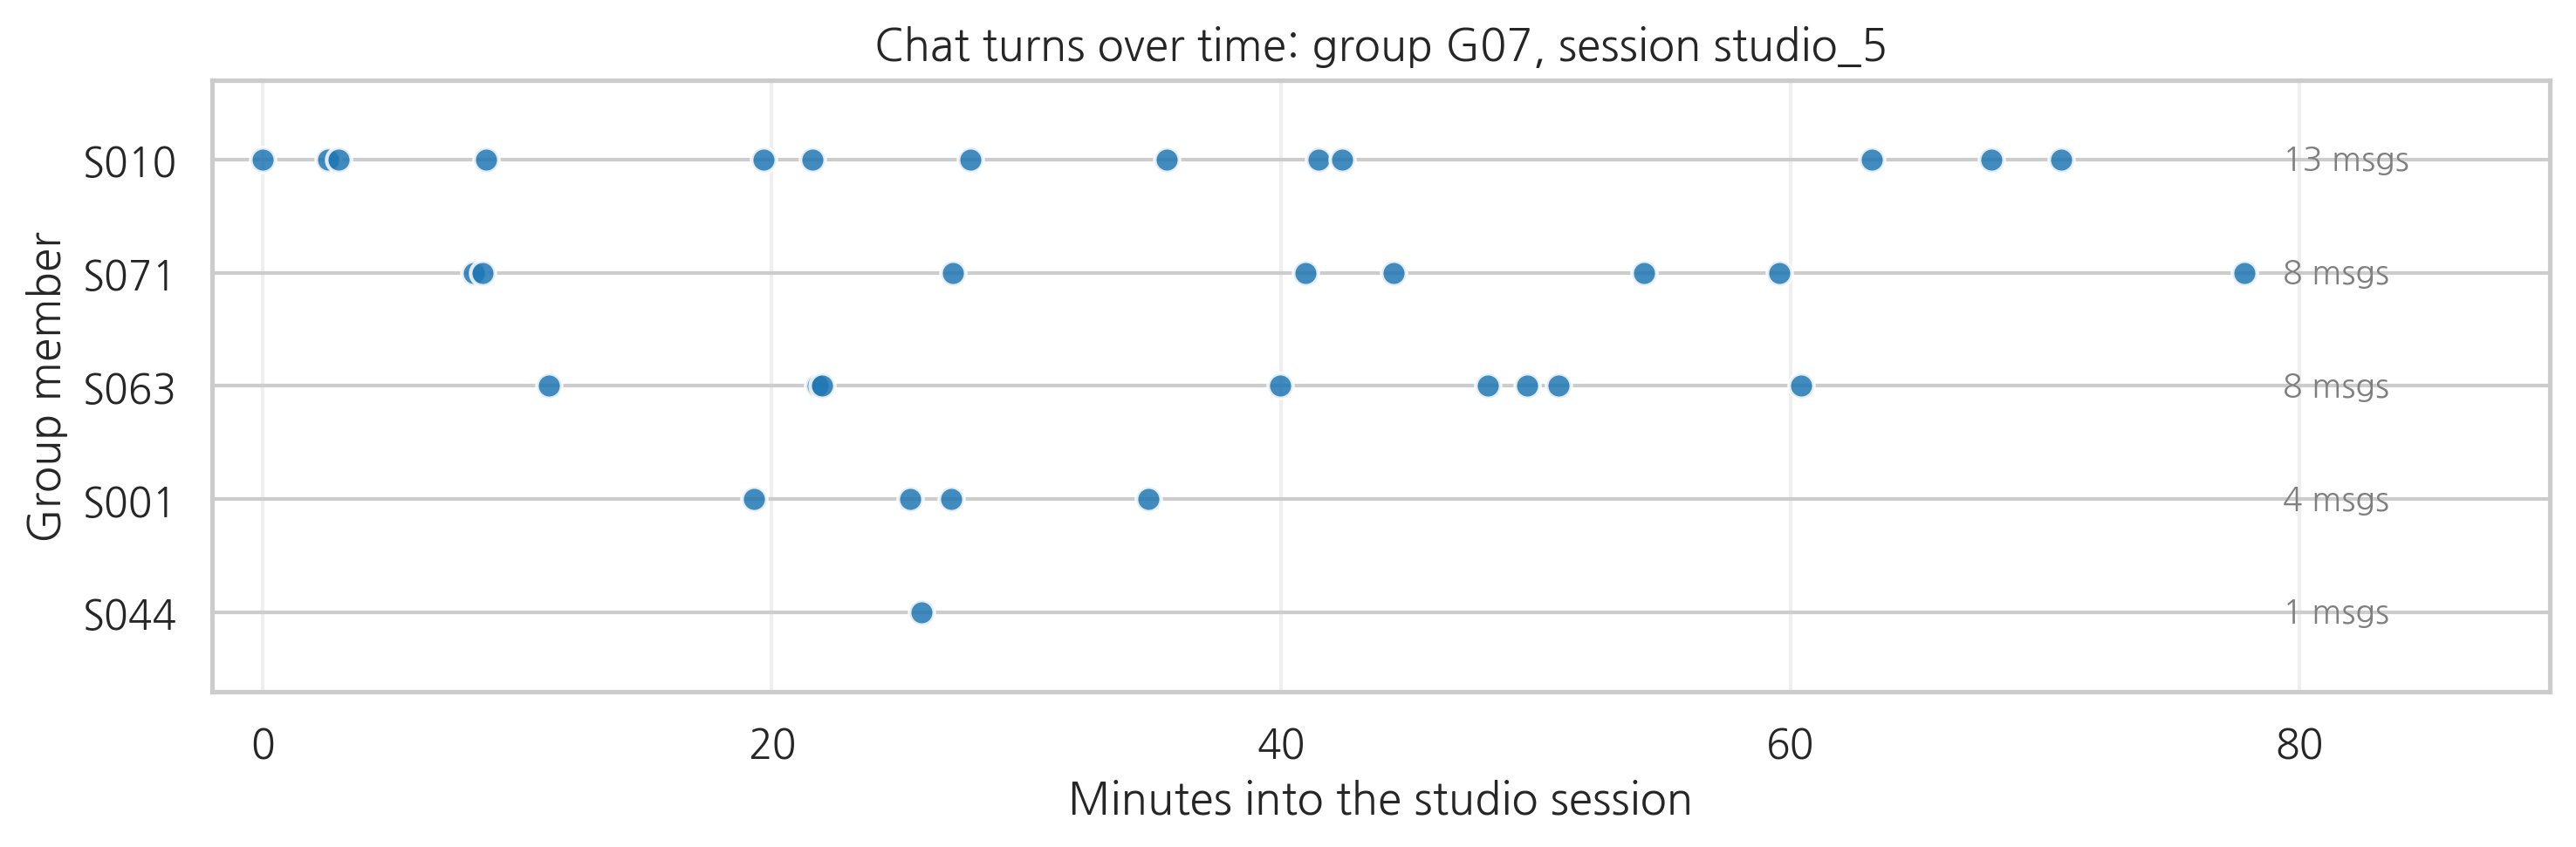

Share of this session's chat messages, by member (%):
student_id
S010    38.2
S063    23.5
S071    23.5
S001    11.8
S044     2.9


In [4]:
def plot_turn_raster(group_id, session_id):
    # Plot every chat message of one group-session as a dot on a timeline.
    one = chat[(chat.group_id == group_id) & (chat.session_id == session_id)].copy()
    roster = sorted(mmla.loc[(mmla.group_id == group_id) &
                             (mmla.session_id == session_id), "student_id"])
    counts = one.student_id.value_counts().reindex(roster).fillna(0).astype(int)
    order = counts.sort_values().index.tolist()          # quietest at the bottom
    ypos = {sid: i for i, sid in enumerate(order)}
    start = one.timestamp.min()
    one["minutes"] = (one.timestamp - start).dt.total_seconds() / 60.0

    fig, ax = plt.subplots(figsize=(10, 3.4))
    for sid in order:
        sub = one[one.student_id == sid]
        ax.scatter(sub.minutes, [ypos[sid]] * len(sub), s=46, color=BLUE,
                   alpha=0.85, edgecolor="white", zorder=3)
        ax.text(one.minutes.max() + 1.5, ypos[sid], f"{counts[sid]} msgs",
                va="center", fontsize=9, color=GRAY)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_ylim(-0.7, len(order) - 0.3)
    ax.set_xlim(-2, one.minutes.max() + 12)
    ax.set_xlabel("Minutes into the studio session")
    ax.set_ylabel("Group member")
    ax.set_title(f"Chat turns over time: group {group_id}, session {session_id}")
    ax.grid(axis="x", alpha=0.3, zorder=0)
    fig.tight_layout()
    plt.show()

    share = (counts / counts.sum() * 100).round(1).sort_values(ascending=False)
    print("Share of this session's chat messages, by member (%):")
    print(share.to_string())

plot_turn_raster("G07", "studio_5")

**🧐 Interpret this chart before you scroll.**

- Where in the session is the chat densest, and what do you imagine is happening in the room at that moment?
- One member of this group posted once. Before you reach for any explanation about that person, work
  the other three places an explanation could live, and name a candidate in each. **The instrument:**
  what does a chat log fail to record about five people in a room with live voices and a shared
  document? **The setting:** what about how this studio is run could make typing unnecessary for one
  member and necessary for another? **The circumstances:** what could be true of a Thursday afternoon
  that this file has no column for? Only after those three have real candidates in them is anything
  about the student one hypothesis among several.
- The dots do not distinguish "I can share my screen" from "I think the testing effect only worked because
  the retrieval was effortful." Does that matter for what you are about to compute?

### ✏️ Your turn 1: look at a different room

Change the two values below and rerun the cell. There are 24 groups (`G01` to `G24`) and 8 sessions
(`studio_1` to `studio_8`). The defaults already work, so nothing downstream depends on your edit.

Then do the harder half. Find a session whose shape makes you want to ask a question about it, and
write one sentence naming the standard you just applied: what were you comparing this room against,
and where did that comparison come from? Whatever word arrived first, *uneven*, *quiet*, *unhealthy*,
*fine*, is a construct you brought with you. The raster measured the timestamps on messages. It did
not measure any of those things.

Keep the sentence. You will need it in Section 5, because it is the same sentence a dashboard writes
on your behalf when nobody is watching it do so.

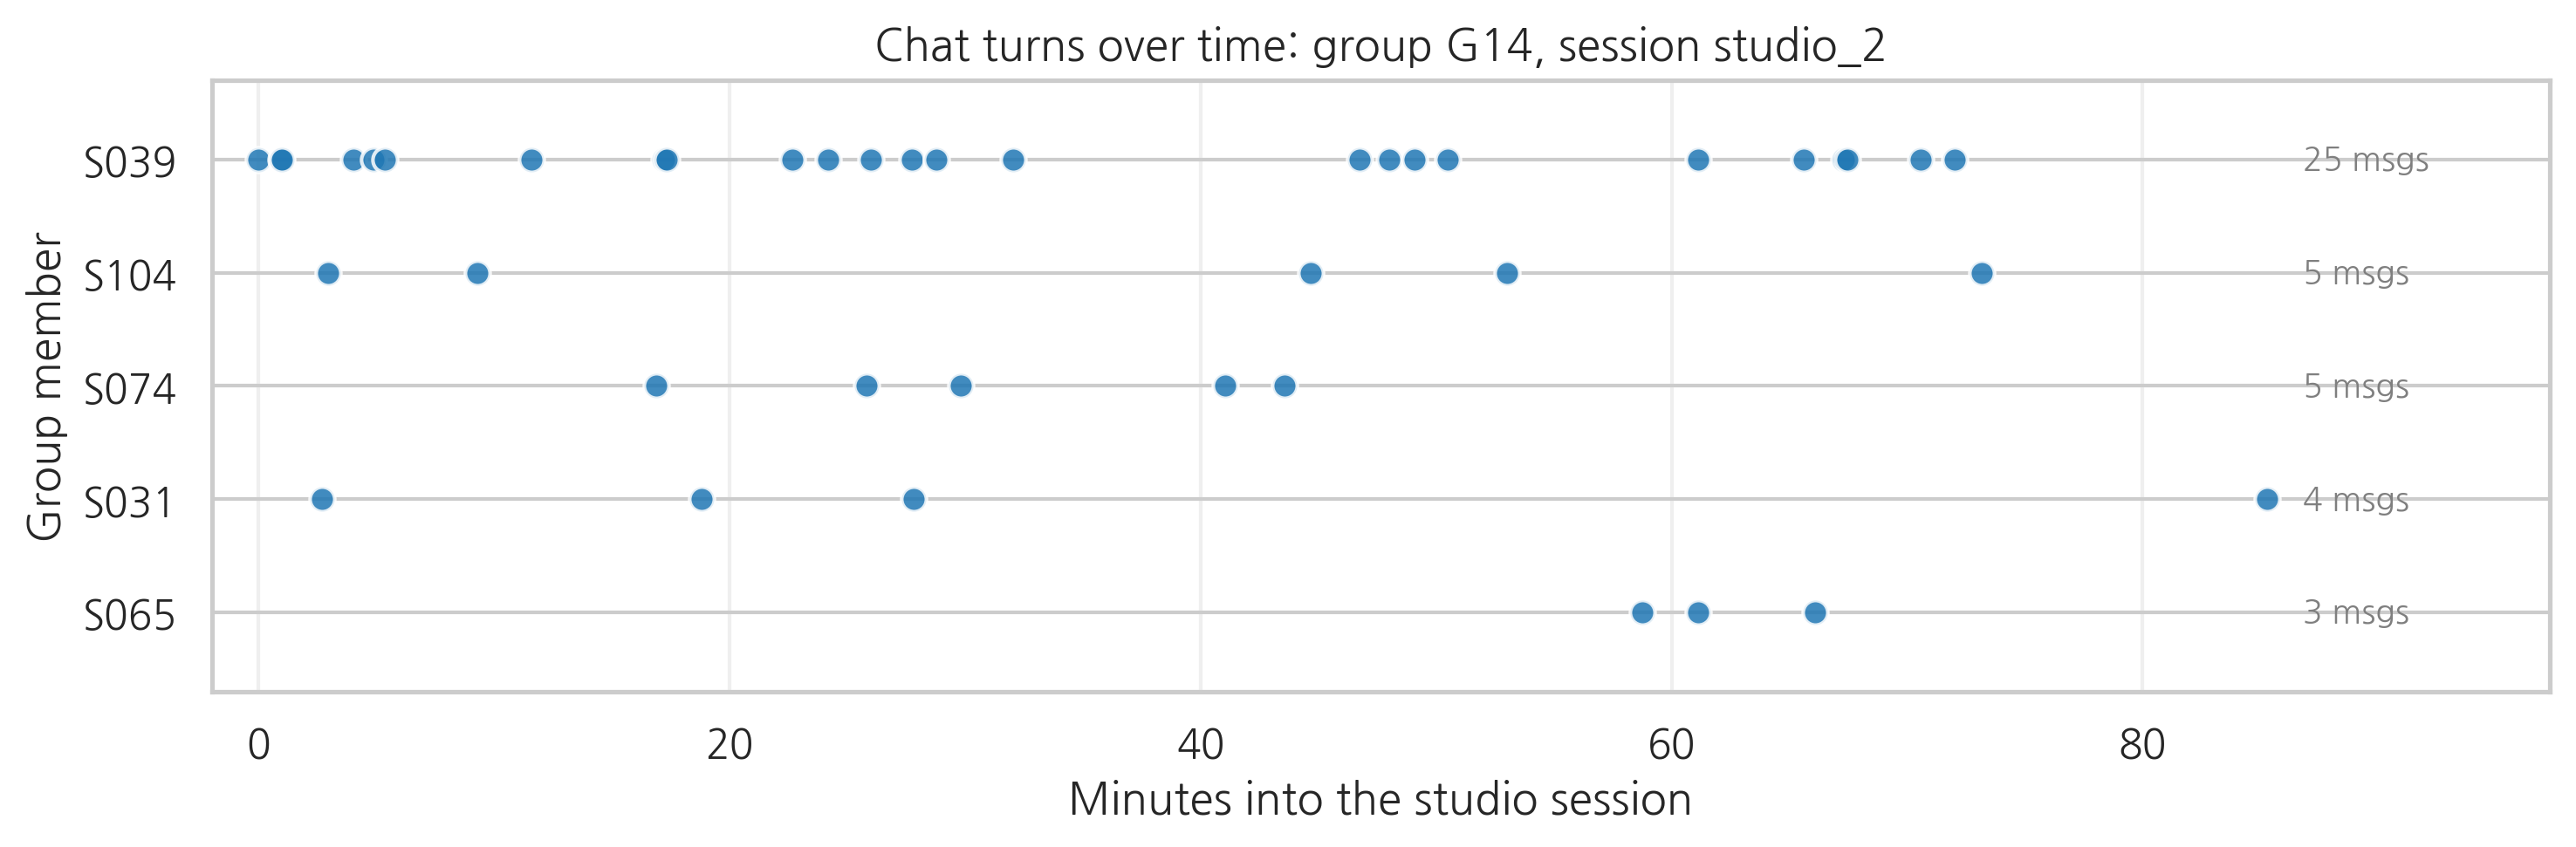

Share of this session's chat messages, by member (%):
student_id
S039    59.5
S074    11.9
S104    11.9
S031     9.5
S065     7.1


In [5]:
# TODO: change these two values and rerun. Any group G01 to G24, any session studio_1 to studio_8.
MY_GROUP = "G14"
MY_SESSION = "studio_2"

plot_turn_raster(MY_GROUP, MY_SESSION)

---

## 📊 Section 2. Response latency, and a cautionary tale about metrics

"How fast does this group answer each other" sounds like a clean indicator of a responsive team, and it
is the kind of tile that ends up on a dashboard with a green checkmark next to it. So let us build it
honestly and then try to break it.

We compute, for each group-session, the **median number of seconds until somebody else replies**. Median
rather than mean, because a single 20 minute silence while the group works in the shared doc would drag a
mean around by itself.

The second panel is the test: we plot each group-session's median latency against how many messages that
session contained. If the metric is measuring responsiveness, those two things should be able to come
apart. Watch whether they do, and before you look, do the arithmetic in your head. A studio session
runs for a fixed stretch of clock. If a group sends more messages into a fixed window, the typical gap
between messages has to get smaller, whether or not anybody is being more responsive to anybody.

The cell also prints two robustness checks, because a single Pearson *r* on skewed counts is not an
answer: Spearman's rank correlation alongside it, and the second latency definition from Section 1.

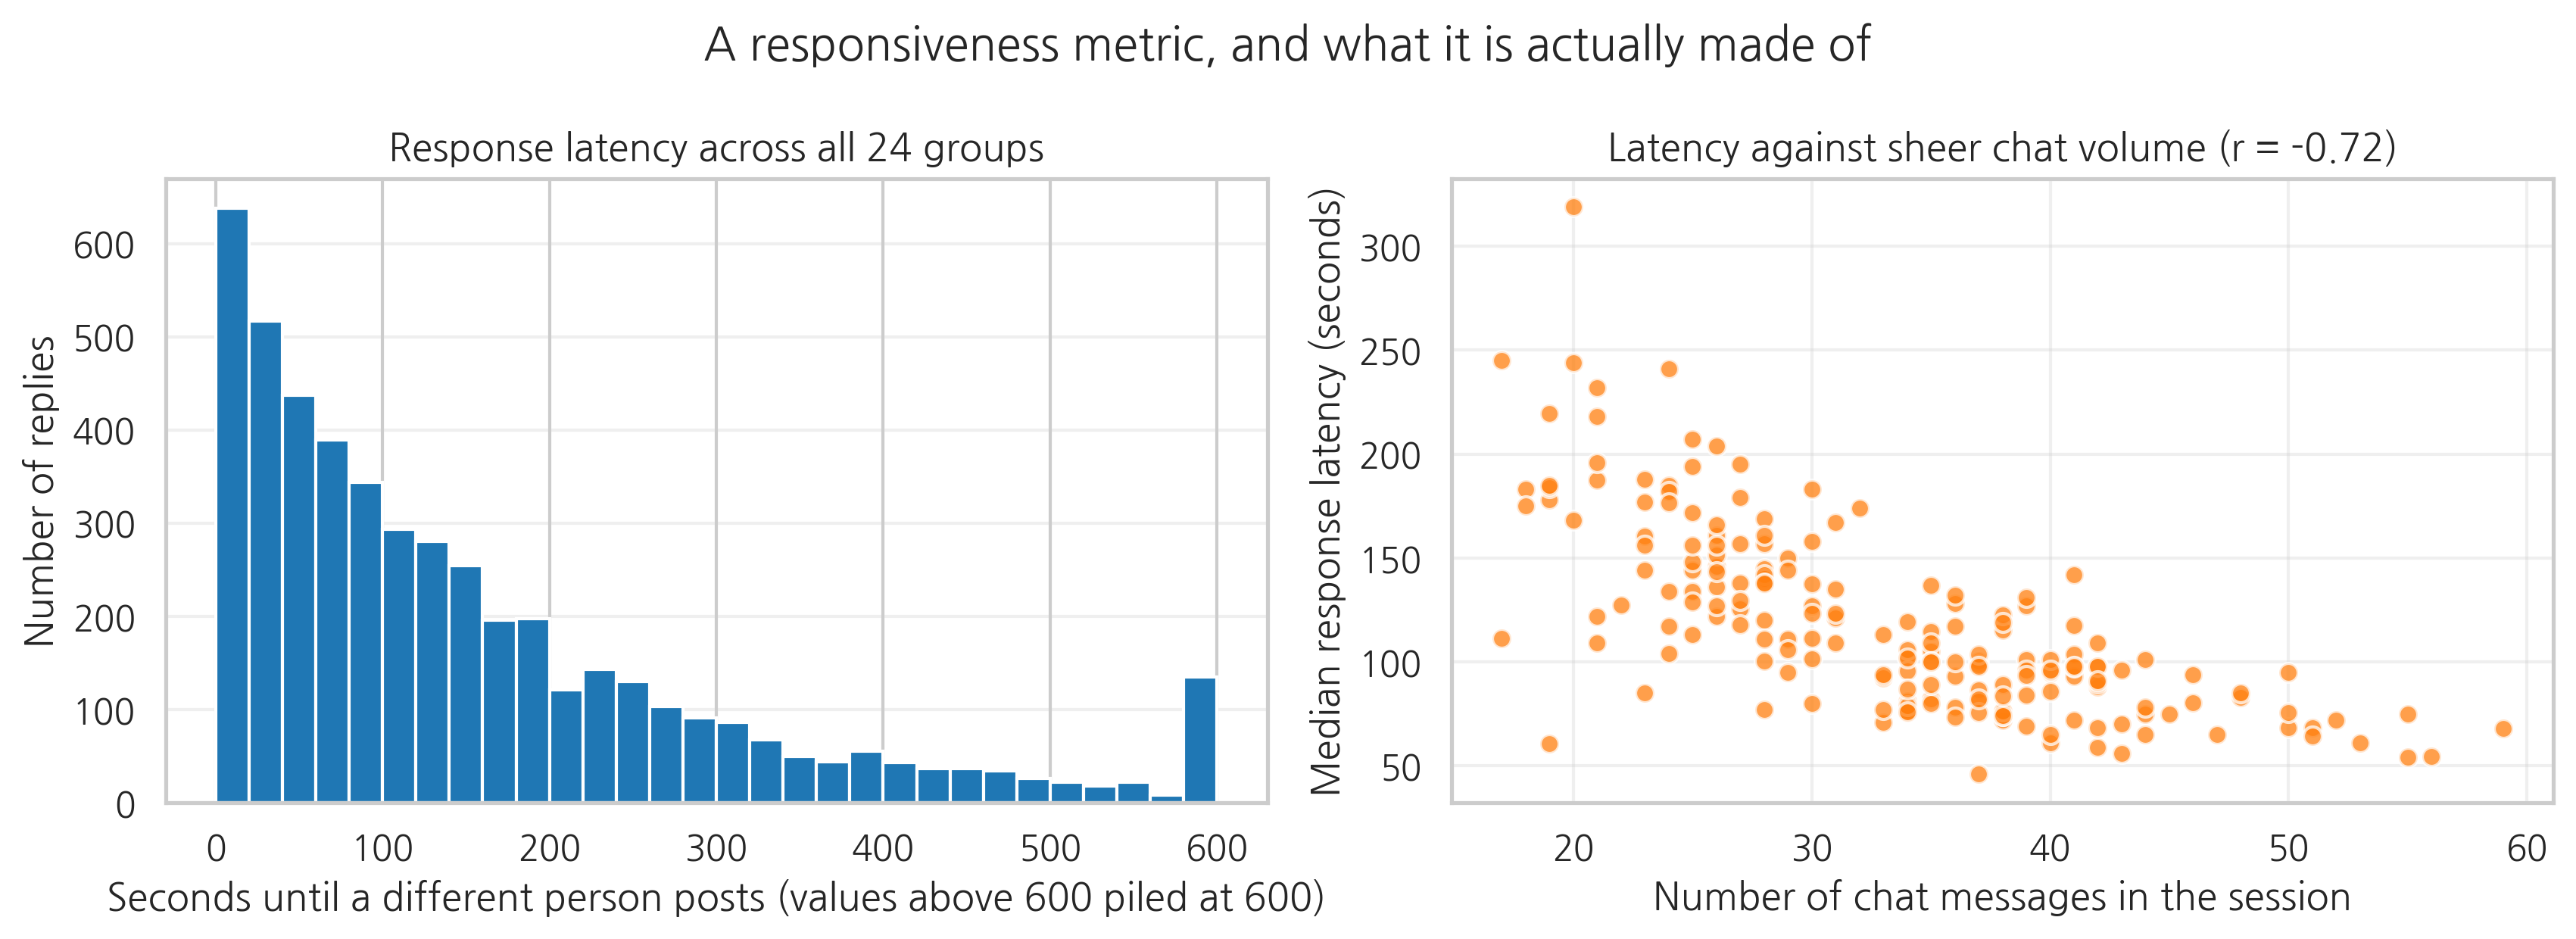

Median latency across all group-sessions: 108 s
Fastest group-session: 46 s | slowest: 319 s
Correlation between session message count and median latency: Pearson r = -0.72, Spearman rho = -0.76

The arithmetic underneath that correlation:
  A session's messages span 82 minutes at the median (middle half: 80 to 84 minutes).
  Divide that span by the number of gaps in it and you get a purely mechanical latency.
  It correlates with the measured median latency at r = 0.77.

Decision 3, computed both ways (median across the 192 group-sessions):
  gap to the next message, when a new person posts it : 108 s
  gap to the next message by anybody else             : 143 s
  Same construct, same sentence in English, one third apart.

Largest gap inside any single group-session: 26 minutes. A 'thirty minutes of silence starts a new session' rule
  would therefore have recovered exactly these session boundaries, which is luck, not method.

Median latency by how busy the session was:
              

In [6]:
switches = chat[chat.is_switch & chat.gap_s.notna()]

session_stats = (chat.groupby(["group_id", "session_id"])
                     .agg(n_messages=("message_id", "size"),
                          span_s=("timestamp", lambda t: (t.max() - t.min()).total_seconds()))
                     .reset_index())
latency = (switches.groupby(["group_id", "session_id"])["gap_s"]
                   .median().rename("median_latency_s").reset_index())
session_stats = session_stats.merge(latency, on=["group_id", "session_id"])

r_latency = session_stats.n_messages.corr(session_stats.median_latency_s)
rho_latency = session_stats.n_messages.corr(session_stats.median_latency_s, method="spearman")

# --- Decision 3, the other way round: time to the next message by ANYBODY else, skipping the
# --- writer's own follow-up lines. A "run" is one person's uninterrupted streak of messages.
runs = (chat.groupby(["group_id", "session_id"], sort=False)["student_id"]
            .apply(lambda s: (s != s.shift()).cumsum()))
chat["run_id"] = runs.to_numpy()
run_start = (chat.groupby(["group_id", "session_id", "run_id"])["timestamp"]
                 .first().rename("run_start").reset_index())
run_start["next_run_start"] = run_start.groupby(["group_id", "session_id"])["run_start"].shift(-1)
chat_alt = chat.merge(run_start[["group_id", "session_id", "run_id", "next_run_start"]],
                      on=["group_id", "session_id", "run_id"], how="left")
chat_alt["gap_alt_s"] = (chat_alt.next_run_start - chat_alt.timestamp).dt.total_seconds()
alt_latency = (chat_alt.groupby(["group_id", "session_id"])["gap_alt_s"]
                       .median().rename("median_latency_alt_s"))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].hist(switches.gap_s.clip(upper=600), bins=np.arange(0, 620, 20),
             color=BLUE, edgecolor="white")
axes[0].set_xlabel("Seconds until a different person posts (values above 600 piled at 600)")
axes[0].set_ylabel("Number of replies")
axes[0].set_title("Response latency across all 24 groups")
axes[0].grid(axis="y", alpha=0.3)

axes[1].scatter(session_stats.n_messages, session_stats.median_latency_s,
                color=ORANGE, alpha=0.75, edgecolor="white")
axes[1].set_xlabel("Number of chat messages in the session")
axes[1].set_ylabel("Median response latency (seconds)")
axes[1].set_title(f"Latency against sheer chat volume (r = {r_latency:.2f})")
axes[1].grid(alpha=0.3)

fig.suptitle("A responsiveness metric, and what it is actually made of")
fig.tight_layout()
plt.show()

print(f"Median latency across all group-sessions: {session_stats.median_latency_s.median():.0f} s")
print(f"Fastest group-session: {session_stats.median_latency_s.min():.0f} s | "
      f"slowest: {session_stats.median_latency_s.max():.0f} s")
print(f"Correlation between session message count and median latency: "
      f"Pearson r = {r_latency:.2f}, Spearman rho = {rho_latency:.2f}")

print("\nThe arithmetic underneath that correlation:")
print(f"  A session's messages span {session_stats.span_s.median() / 60:.0f} minutes at the median "
      f"(middle half: {session_stats.span_s.quantile(.25) / 60:.0f} to "
      f"{session_stats.span_s.quantile(.75) / 60:.0f} minutes).")
print(f"  Divide that span by the number of gaps in it and you get a purely mechanical latency.")
print(f"  It correlates with the measured median latency at r = "
      f"{session_stats.median_latency_s.corr(session_stats.span_s / (session_stats.n_messages - 1)):.2f}.")

print("\nDecision 3, computed both ways (median across the 192 group-sessions):")
print(f"  gap to the next message, when a new person posts it : "
      f"{session_stats.median_latency_s.median():.0f} s")
print(f"  gap to the next message by anybody else             : {alt_latency.median():.0f} s")
print("  Same construct, same sentence in English, one third apart.")

biggest_gap = chat.gap_s.max()
print(f"\nLargest gap inside any single group-session: {biggest_gap / 60:.0f} minutes. A 'thirty "
      f"minutes of silence starts a new session' rule\n  would therefore have recovered exactly these "
      f"session boundaries, which is luck, not method.")

print("\nMedian latency by how busy the session was:")
session_stats["volume_band"] = pd.qcut(session_stats.n_messages, 3,
                                       labels=["quiet third", "middle third", "busy third"])
print(session_stats.groupby("volume_band", observed=True)
                   .agg(sessions=("median_latency_s", "size"),
                        median_latency_s=("median_latency_s", "median")).round(1).to_string())

**🧐 Interpret this chart before you scroll.**

- The left panel is heavily skewed: most replies land quickly and a long tail waits minutes. Which number
  would you put on a dashboard, the mean or the median, and what does each one hide?
- The right panel is the uncomfortable one, and the printed arithmetic says why. The session length is
  close to fixed, so the median gap between messages is close to (session length) divided by (number of
  messages), and the printout shows that mechanical quantity tracking the measured latency at r = 0.77.
  A group's median latency is therefore largely a restatement of how many messages the group sent, and
  it would be even if nobody in either room were listening to anybody. Is this metric measuring
  responsiveness, or chattiness?
- Notice that the same English sentence, "how long until somebody else replies," produced 108 seconds
  under one reading and 143 under the other. Neither is wrong. Which one you write into the code
  decides which groups look slow, and nothing in the data will tell you which to pick.
- Suppose a teacher sees a group flagged "slow to respond." Name one intervention that would help if the
  flag means what it says, and one harm that follows if it means what the right panel suggests.

This is the first candidate for the closing question. Hold it: **should a collaboration dashboard show a
latency tile at all?**

---

## 📊 Section 3. Participation equity, now measured in a second channel

You already know the Gini coefficient from Week 6, including the part most dashboards get wrong.
Zero means every member contributed exactly the same amount. The **maximum is not 1**. For a group
of *n* people the ceiling is (n - 1)/n, so for a group of five it is **0.8**, reached only when one
person does literally everything and the other four do nothing at all. Week 6 derived this; we are
not re-deriving it, we are re-pointing the same measure at a second channel. Read every Gini below
against 0.8, not against 1.0.

In Week 6 you fed it speaking time. Now we feed it chat message counts for the same 192 group-sessions,
and the only genuinely new step is a boring one that matters enormously: **a member who sent zero
messages does not appear in `group_chat.csv` at all.** If you compute a Gini over only the people who
show up in the log, you compute the equity of the people who participated, which is a very different
quantity. We rebuild the full five person roster from `mmla_studio.csv` first, and fill the silent ones
in as zeros.

In [7]:
def gini(values):
    # Gini of a set of non-negative contributions. 0 = perfectly even, 1 = one person holds it all.
    v = np.sort(np.asarray(values, dtype=float))
    n = v.size
    total = v.sum()
    if n == 0 or total <= 0:
        return 0.0
    index = np.arange(1, n + 1)
    return float((2.0 * np.sum(index * v)) / (n * total) - (n + 1.0) / n)

# Full roster of five members per group-session, from the attendance-complete MMLA file.
roster = mmla[["group_id", "session_id", "student_id"]]
msg_counts = (chat.groupby(["group_id", "session_id", "student_id"])
                  .size().rename("n_messages").reset_index())
per_member = (roster.merge(msg_counts, on=["group_id", "session_id", "student_id"], how="left")
                    .fillna({"n_messages": 0}))

n_silent = int((per_member.n_messages == 0).sum())
print(f"Member-sessions with zero chat messages: {n_silent} out of {len(per_member)}")
print("Those rows would have vanished if we had trusted the chat log alone.\n")

equity = (per_member.groupby(["group_id", "session_id"])["n_messages"]
                    .apply(gini).rename("gini_chat").reset_index())
equity_talk = (mmla.groupby(["group_id", "session_id"])["speaking_time_s"]
                   .apply(gini).rename("gini_speaking").reset_index())
equity = (equity.merge(equity_talk, on=["group_id", "session_id"])
                .merge(artifacts, on=["group_id", "session_id"]))

print(equity[["gini_chat", "gini_speaking", "artifact_score"]].describe().round(3).to_string())
print("\nFor scale: with five members per group the Gini ceiling is 0.8, not 1.0.")
print(f"The most concentrated chat here reaches {equity.gini_chat.max():.2f} "
      f"({equity.gini_chat.max() / 0.8:.0%} of that ceiling); the most concentrated talk reaches "
      f"{equity.gini_speaking.max():.2f} ({equity.gini_speaking.max() / 0.8:.0%}).")

Member-sessions with zero chat messages: 9 out of 960
Those rows would have vanished if we had trusted the chat log alone.

       gini_chat  gini_speaking  artifact_score
count    192.000        192.000         192.000
mean       0.238          0.348           6.638
std        0.079          0.127           1.390
min        0.038          0.070           2.900
25%        0.172          0.251           5.775
50%        0.235          0.330           6.700
75%        0.289          0.427           7.500
max        0.429          0.681          10.000

For scale: with five members per group the Gini ceiling is 0.8, not 1.0.
The most concentrated chat here reaches 0.43 (54% of that ceiling); the most concentrated talk reaches 0.68 (85%).


### Do the two channels agree about which groups are unequal?

Each dot below is one group-session, plotted by its speaking time Gini (Week 6's measure) against its
chat Gini (this week's). If the backchannel were simply an echo of the room, the dots would cluster
along a rising line. The dashed diagonal marks perfect agreement.

The two dashed gray lines split the cloud at each measure's median, which lets us count the group-sessions
where the two channels disagree outright.

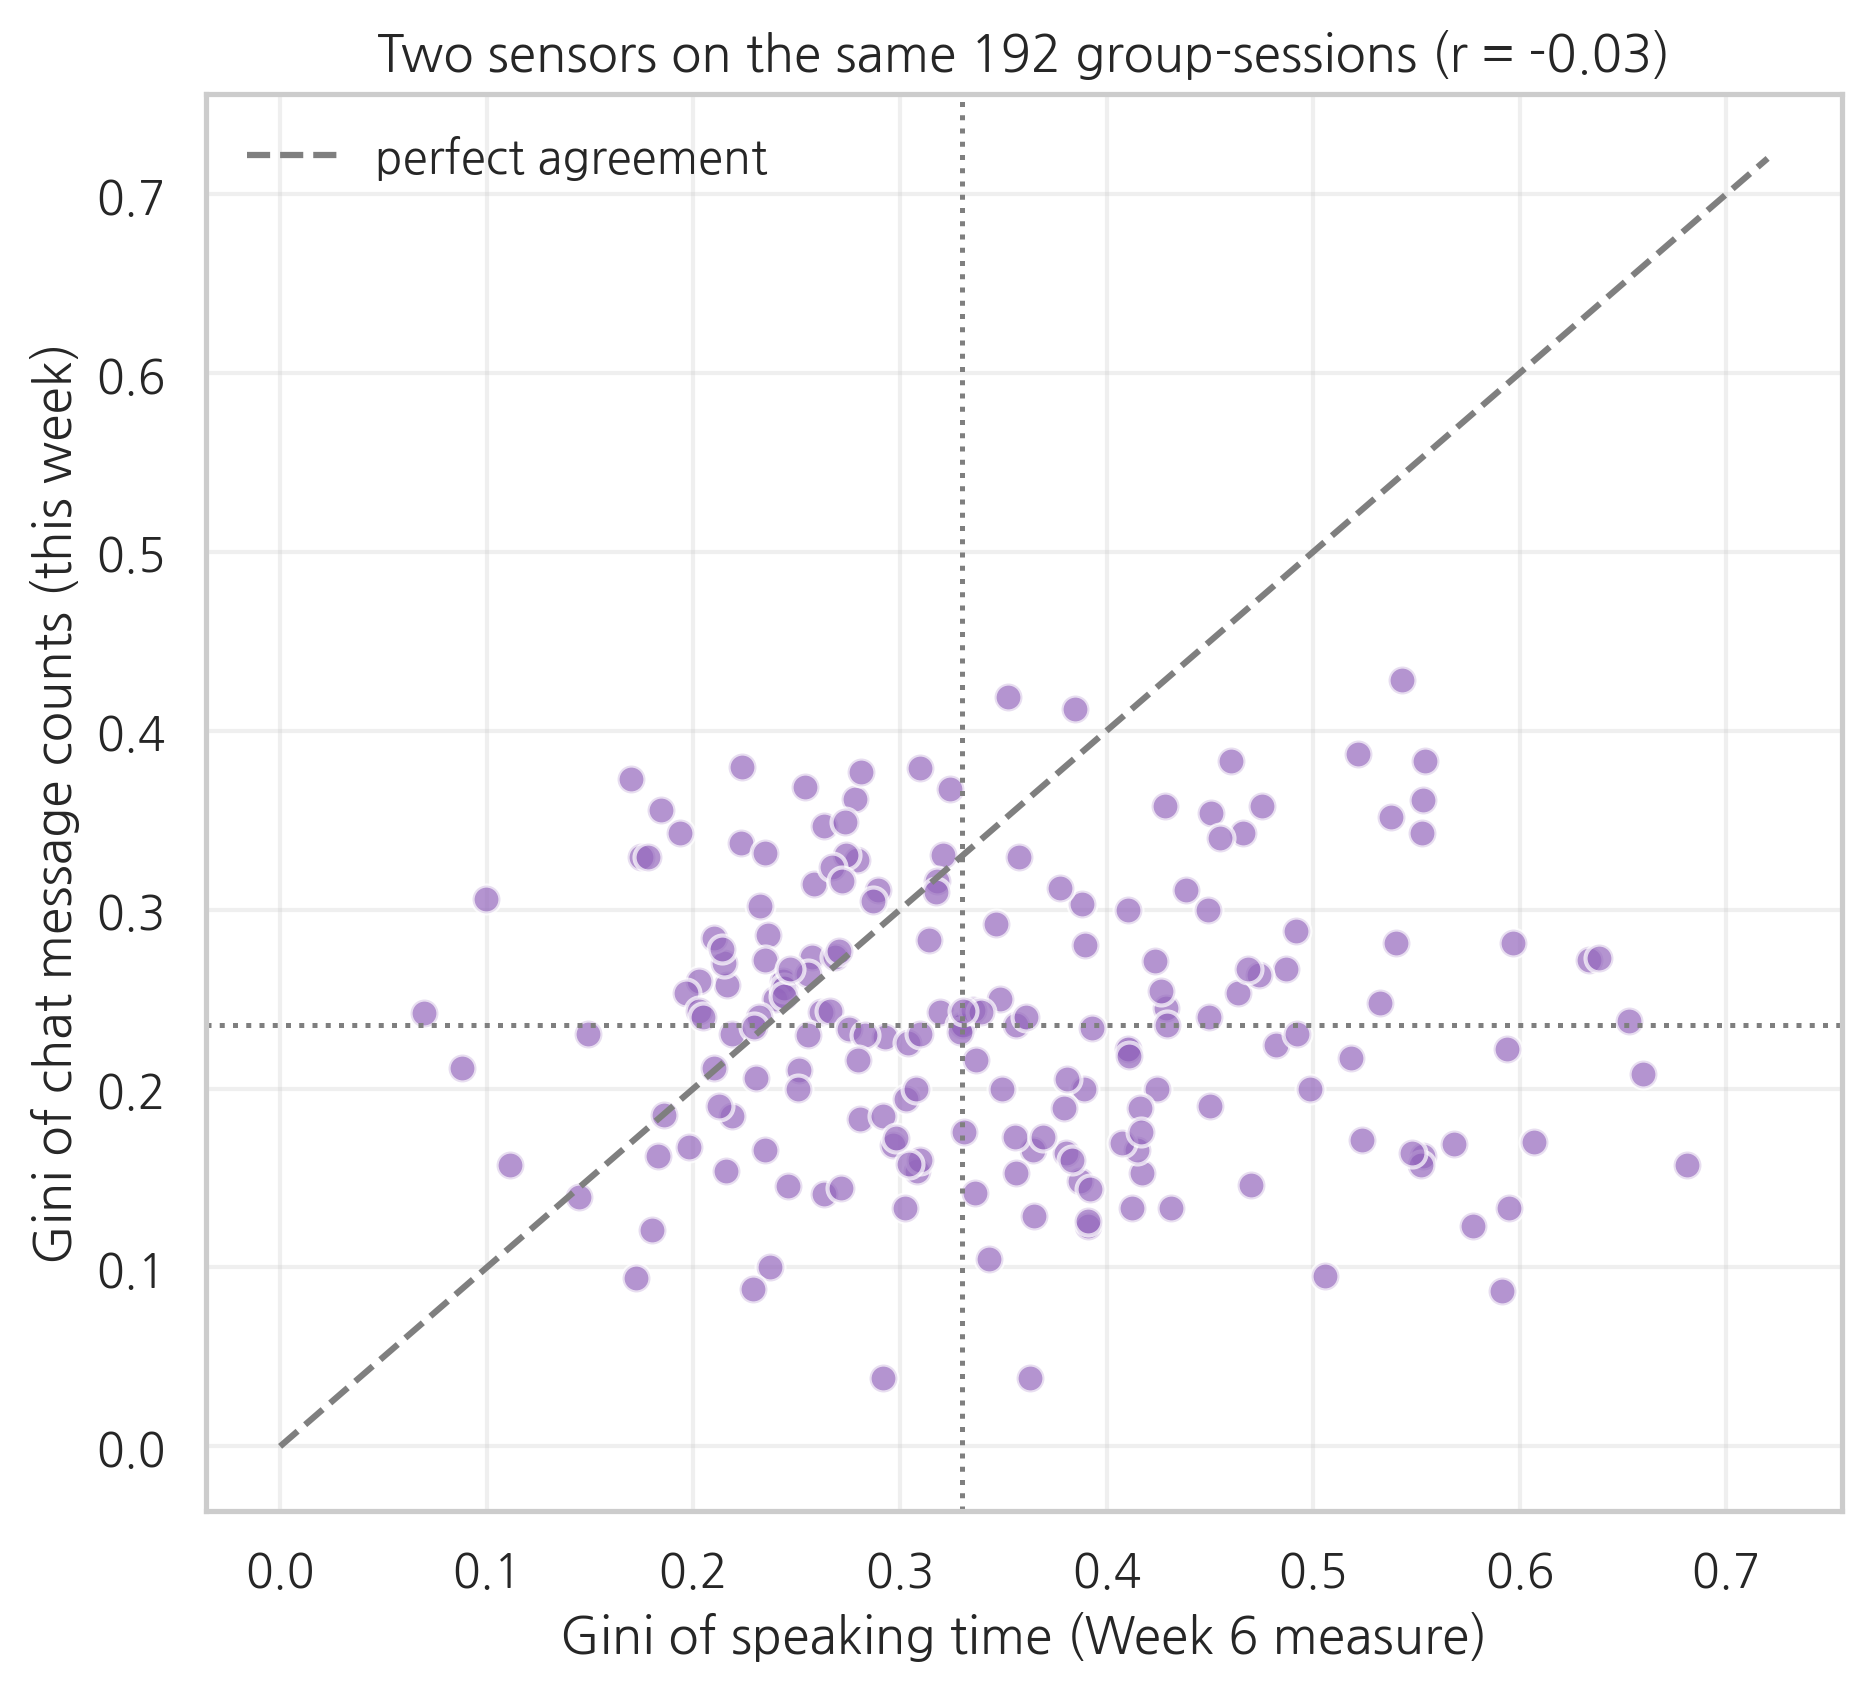

How often do the two channels disagree? (median split, 192 group-sessions)

col_0         chat: even  chat: uneven
row_0                                 
talk: even            44            52
talk: uneven          54            42

The two channels place 106 of 192 group-sessions (55%) on opposite sides of the median. Chance alone would put about half there.

Pearson r = -0.03, 95% interval [-0.17, +0.11]. Spearman rho = -0.05.
The interval contains zero, and it also excludes any correlation worth calling agreement.


In [8]:
r_channels = equity.gini_speaking.corr(equity.gini_chat)
rho_channels = equity.gini_speaking.corr(equity.gini_chat, method="spearman")


def r_ci(r, n):
    # Fisher z interval for a correlation. Assumes independent observations, which is
    # exactly the assumption Section 5 will make us take back.
    z = np.arctanh(r)
    lo, hi = z - 1.96 / np.sqrt(n - 3), z + 1.96 / np.sqrt(n - 3)
    return np.tanh(lo), np.tanh(hi)


med_talk, med_chat = equity.gini_speaking.median(), equity.gini_chat.median()

fig, ax = plt.subplots(figsize=(6.4, 5.8))
ax.scatter(equity.gini_speaking, equity.gini_chat, color=PURPLE, alpha=0.7,
           edgecolor="white", s=45)
ax.plot([0, 0.72], [0, 0.72], color=GRAY, ls="--", lw=1.5, label="perfect agreement")
ax.axvline(med_talk, color=GRAY, ls=":", lw=1.2)
ax.axhline(med_chat, color=GRAY, ls=":", lw=1.2)
ax.set_xlabel("Gini of speaking time (Week 6 measure)")
ax.set_ylabel("Gini of chat message counts (this week)")
ax.set_title(f"Two sensors on the same 192 group-sessions (r = {r_channels:.2f})")
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

quad = pd.crosstab(np.where(equity.gini_speaking > med_talk, "talk: uneven", "talk: even"),
                   np.where(equity.gini_chat > med_chat, "chat: uneven", "chat: even"))
print("How often do the two channels disagree? (median split, 192 group-sessions)\n")
print(quad.to_string())
disagree = quad.loc["talk: uneven", "chat: even"] + quad.loc["talk: even", "chat: uneven"]
print(f"\nThe two channels place {disagree} of 192 group-sessions "
      f"({disagree / 192:.0%}) on opposite sides of the median. Chance alone would put about half there.")
lo, hi = r_ci(r_channels, len(equity))
print(f"\nPearson r = {r_channels:+.2f}, 95% interval [{lo:+.2f}, {hi:+.2f}]. "
      f"Spearman rho = {rho_channels:+.2f}.")
print("The interval contains zero, and it also excludes any correlation worth calling agreement.")

**🧐 Interpret this chart before you scroll.**

- The correlation is indistinguishable from zero, and the interval is narrow enough to rule out even a
  moderate association. That is a stronger statement than "we found nothing," and it is the one the
  data support. Write the sentence you would say out loud to a colleague who claimed "we measured
  participation equity for these groups."
- Look at the lower right region: groups where one person dominated the talk while the chat stayed even.
  What could be happening in those rooms? Now look at the upper left and do the same.
- Martinez-Maldonado and colleagues (2019) call this the problem of what a modality can license you to
  claim. If your dashboard had only one of these two numbers on it, which claims about a group would you
  no longer be entitled to make?

### Back to P9: does unequal participation go with a weaker group product?

Week 6 found that groups with more evenly shared *speaking time* produced higher rated artifacts. The
honest test of that finding is whether it survives a change of instrument. Below, the same outcome
(`artifact_score`, a 1 to 10 rubric score for the group's product) is plotted against each Gini in turn,
with a least squares line and a three way split of the sessions underneath.

Note that the two panels have different x ranges, because chat is a far more evenly shared channel than
talk in these rooms. Both are measured against the same ceiling of 0.8, so the difference in width is a
real difference between the channels and not a scaling artifact. Compare the slopes, not the widths.

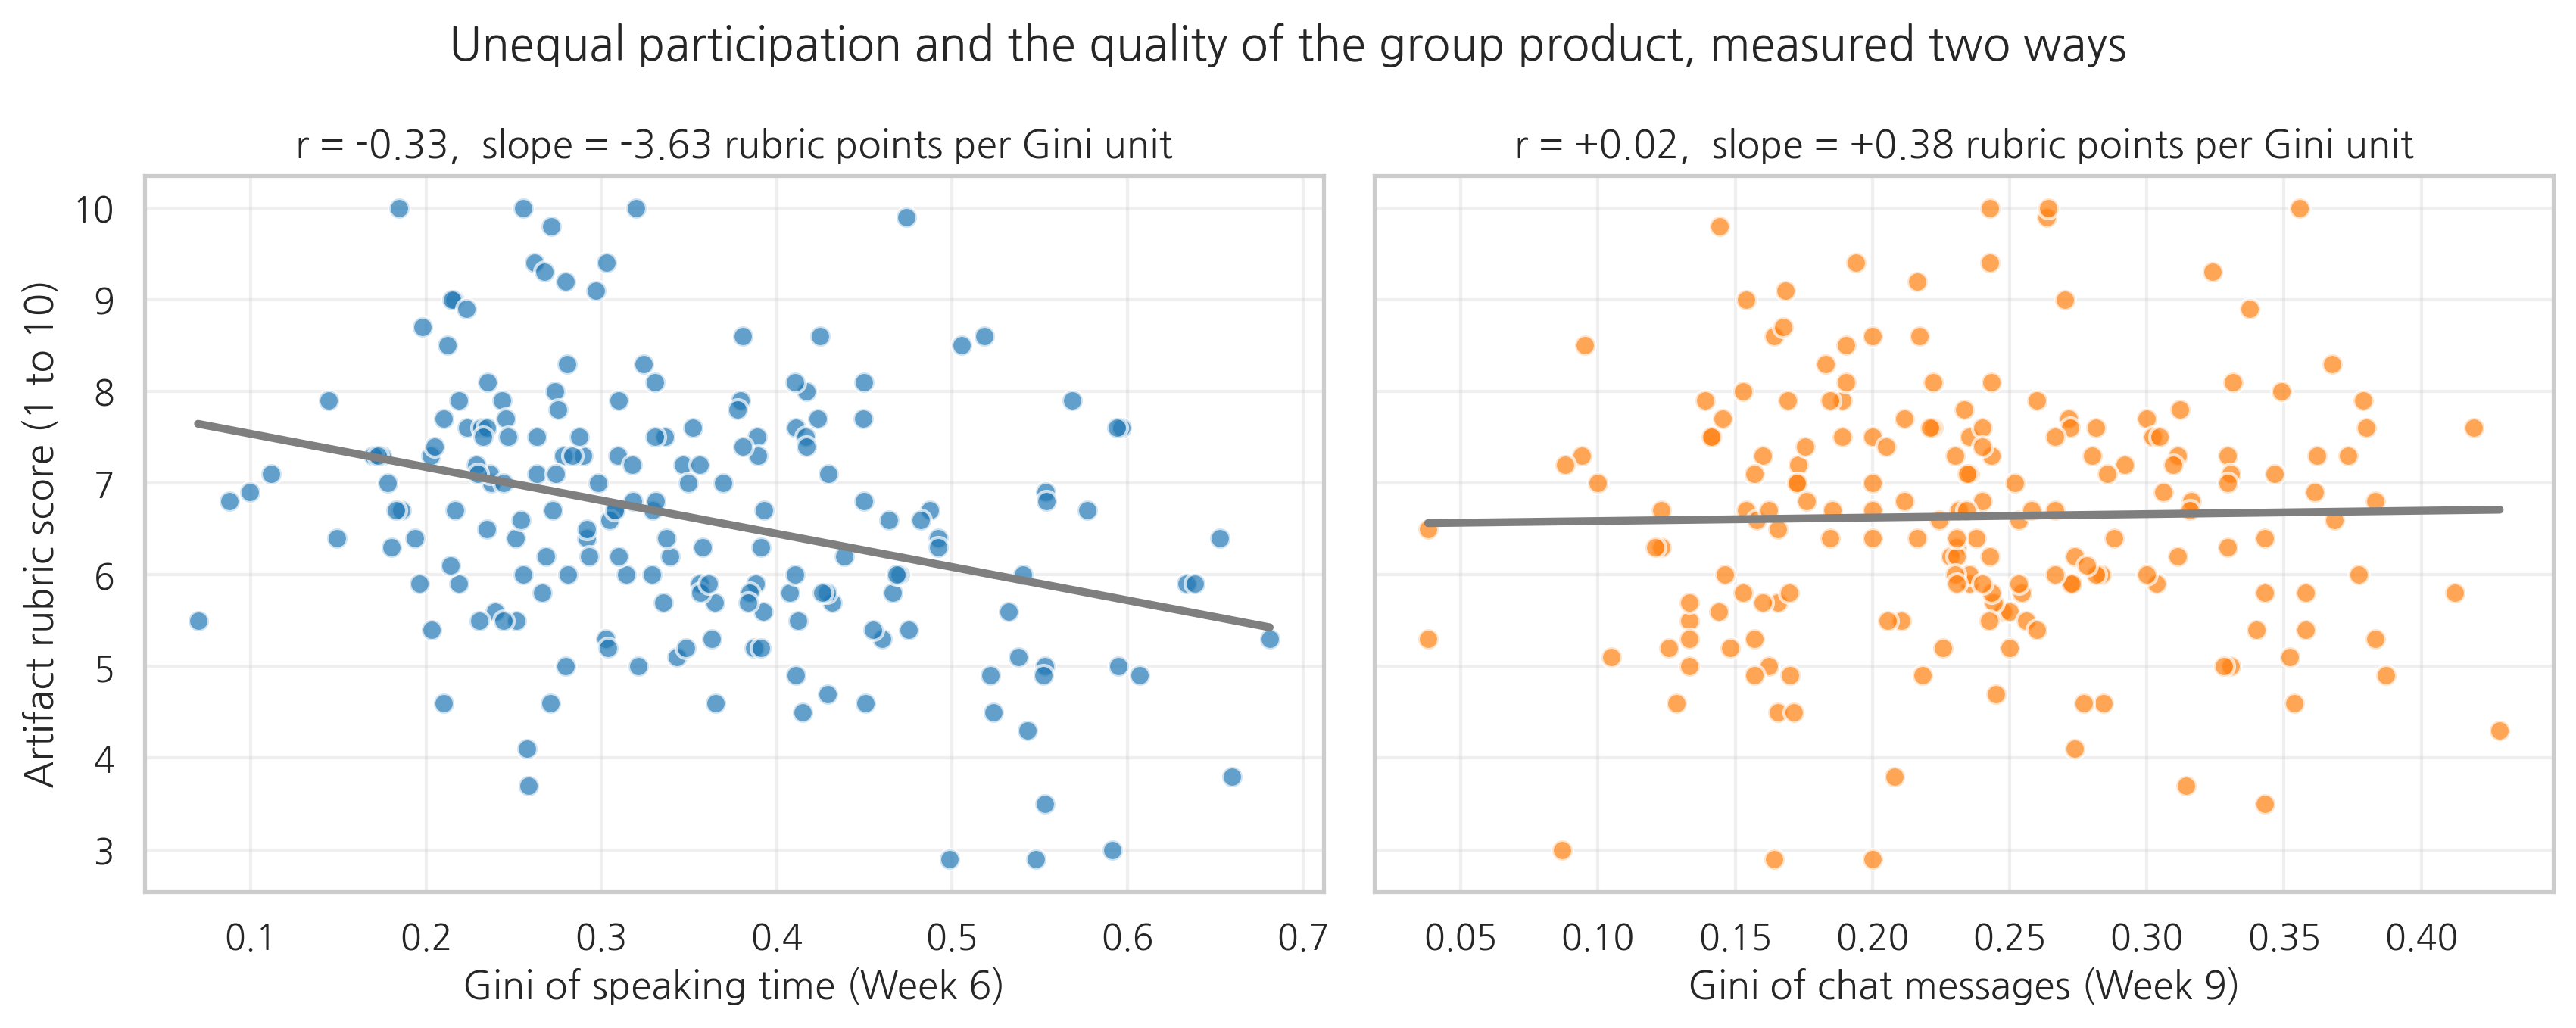

Mean artifact score by participation equity band

                     equity measured by  size  mean   std
most balanced third       speaking time    64  7.05  1.35
middle third              speaking time    64  6.78  1.18
most dominated third      speaking time    64  6.09  1.46
most balanced third       chat messages    68  6.62  1.51
middle third              chat messages    60  6.74  1.30
most dominated third      chat messages    64  6.57  1.35

Same two relationships computed on group means instead (24 groups, one row each):
  equity of speaking time   r = -0.33 across 192 sessions   r = -0.52 across 24 groups
  equity of chat messages   r = +0.02 across 192 sessions   r = -0.10 across 24 groups
Week 6 reported the same pair of numbers for speaking time. Section 5 explains why the
group-level version is the one to quote.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
panels = [("gini_speaking", BLUE, "Gini of speaking time (Week 6)"),
          ("gini_chat", ORANGE, "Gini of chat messages (Week 9)")]

for ax, (col, color, label) in zip(axes, panels):
    ax.scatter(equity[col], equity.artifact_score, color=color, alpha=0.7,
               edgecolor="white", s=42)
    slope, intercept = np.polyfit(equity[col], equity.artifact_score, 1)
    xs = np.linspace(equity[col].min(), equity[col].max(), 30)
    ax.plot(xs, intercept + slope * xs, color=GRAY, lw=2.5)
    r = equity[col].corr(equity.artifact_score)
    ax.set_xlabel(label)
    ax.set_title(f"r = {r:+.2f},  slope = {slope:+.2f} rubric points per Gini unit")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Artifact rubric score (1 to 10)")
fig.suptitle("Unequal participation and the quality of the group product, measured two ways")
fig.tight_layout()
plt.show()

summary = []
for col, label in [("gini_speaking", "speaking time"), ("gini_chat", "chat messages")]:
    bands = pd.qcut(equity[col], 3, labels=["most balanced third", "middle third", "most dominated third"])
    tab = (equity.groupby(bands, observed=True)["artifact_score"]
                 .agg(["size", "mean", "std"]).round(2))
    tab.insert(0, "equity measured by", label)
    summary.append(tab)
print("Mean artifact score by participation equity band\n")
print(pd.concat(summary).to_string())

# The 192 rows are 8 sessions from each of 24 groups, so they are not 192 independent
# observations. Aggregating to one row per group is the crude, honest check.
by_group = equity.groupby("group_id")[["gini_speaking", "gini_chat", "artifact_score"]].mean()
print("\nSame two relationships computed on group means instead (24 groups, one row each):")
for col, label in [("gini_speaking", "speaking time"), ("gini_chat", "chat messages")]:
    r192 = equity[col].corr(equity.artifact_score)
    r24 = by_group[col].corr(by_group.artifact_score)
    print(f"  equity of {label:14s}  r = {r192:+.2f} across 192 sessions   "
          f"r = {r24:+.2f} across 24 groups")
print("Week 6 reported the same pair of numbers for speaking time. Section 5 explains why the")
print("group-level version is the one to quote.")

**🧐 Interpret this chart before you scroll.**

Read the table as carefully as the figure. Measured by speaking time, the most balanced third of sessions
outscores the most dominated third by close to a full rubric point. Measured by chat message counts, the
three bands are indistinguishable.

- Two defensible readings: (a) the chat measure is a worse instrument for the same underlying construct,
  or (b) equal message counts and equal talk are genuinely different constructs and only one of them is
  about who gets to shape the group's thinking. What evidence in this notebook would help you choose?
- A dashboard designer who had only built the chat version would have concluded that participation equity
  does not matter for group work. Say precisely what went wrong in that reasoning chain.
- The Week 6 finding is a correlation. What would have to be true for "equalize the talk and the artifacts
  improve" to follow from it? Name at least two things you cannot check with these data.
- The group-mean version printed under the table is stronger for speaking time (-0.52) than the
  session-level version (-0.33). Before you decide that is good news, say what changed: which source of
  variation did averaging over eight sessions remove, and is the thing it removed noise or is it the
  week-to-week life of a group?

### ✏️ Your turn 2: swap in a better chat measure

Counting messages treats "yes" and "the reading says overconfidence is worst on material that feels
familiar" as the same contribution. `mmla_studio.csv` carries a column called `idea_units_chat`: a human
coder read every chat message from the session and counted the substantive ones.

Change `MEASURE` below to `"idea_units_chat"` and rerun to compute equity on coded ideas rather than raw
message counts. The default (`"chat_messages"`) already runs, so nothing breaks if you leave it alone.

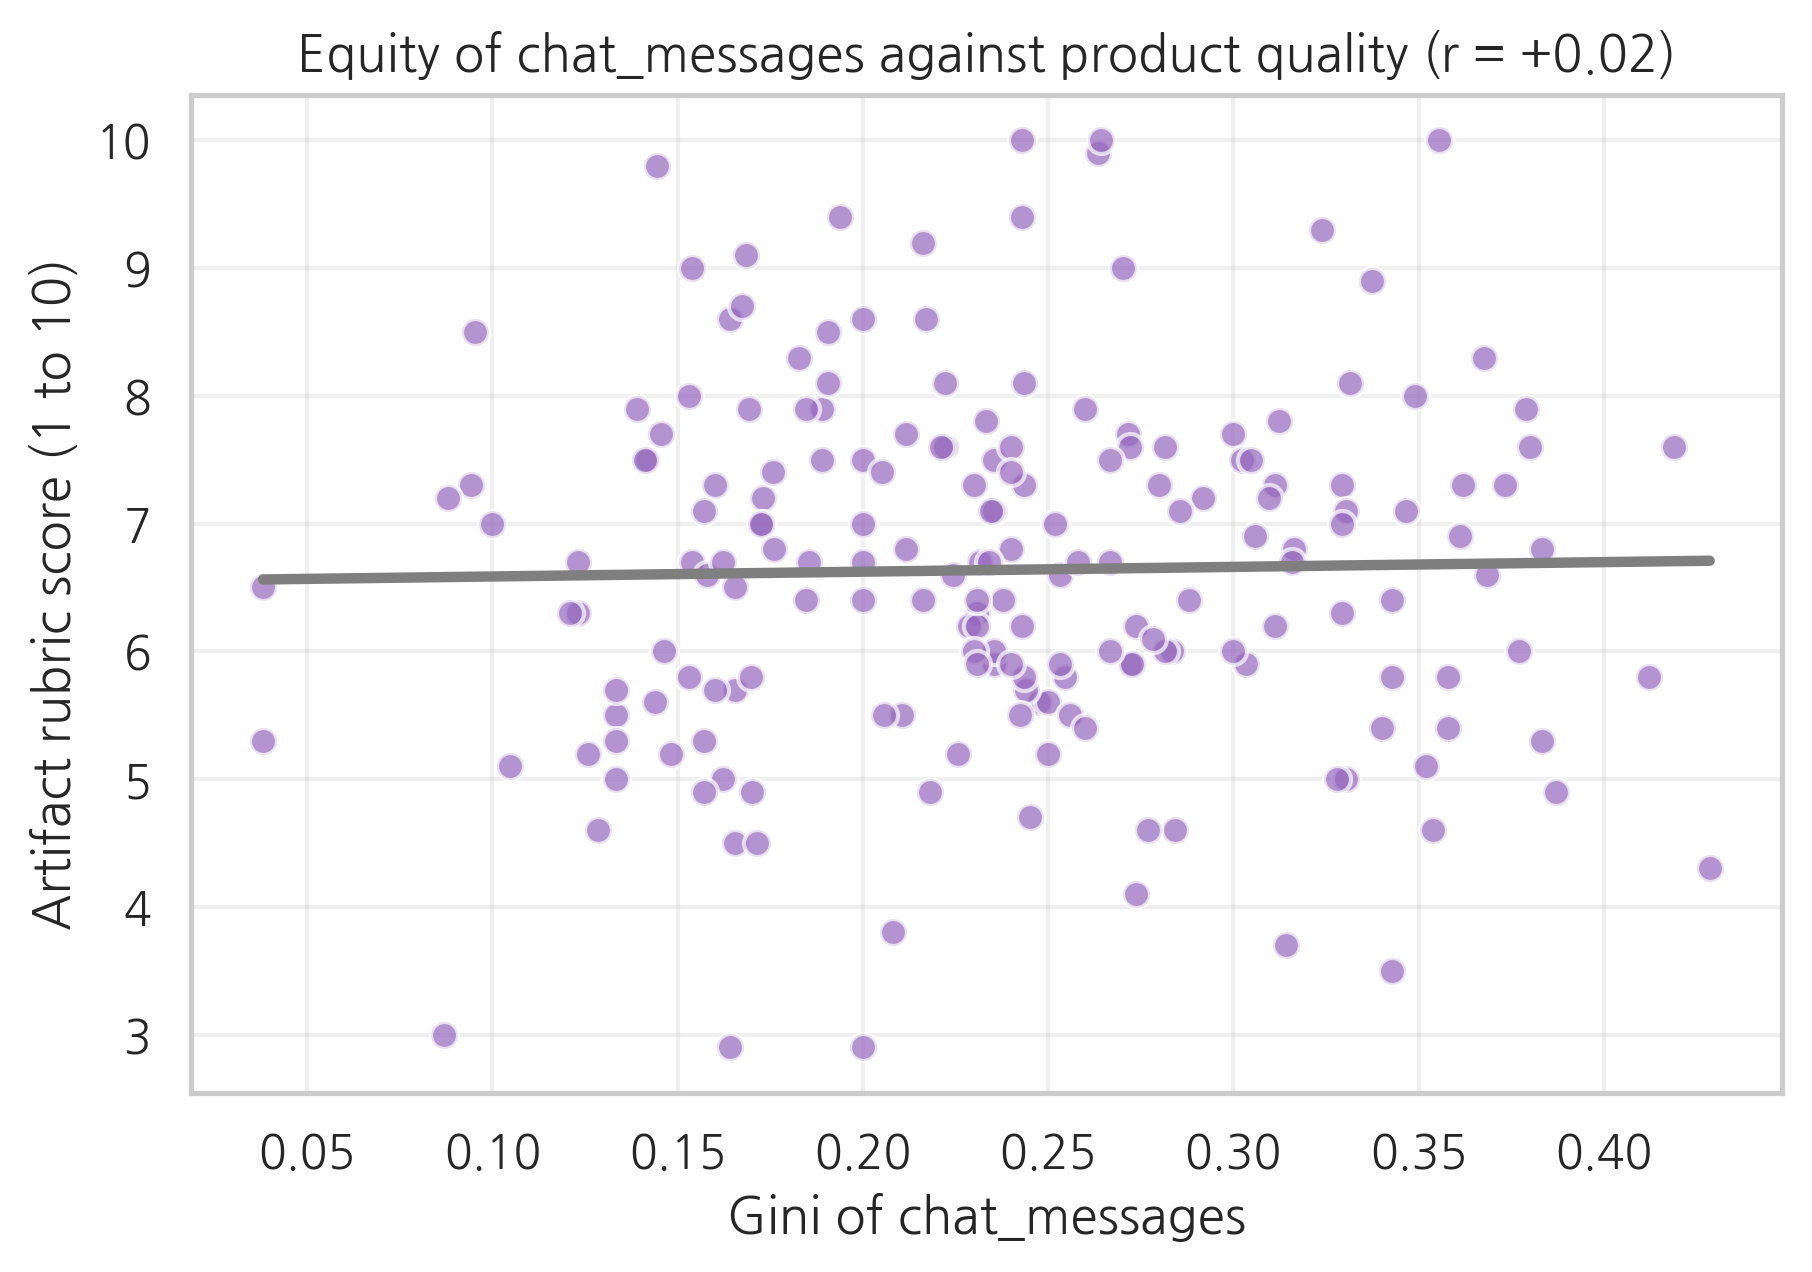

Gini of chat_messages against artifact score: r = +0.02
Range of this Gini across 192 group-sessions: 0.04 to 0.43


In [10]:
# TODO: try "idea_units_chat", then try "doc_edits". Options: chat_messages, idea_units_chat,
# doc_edits, num_turns, speaking_time_s.
MEASURE = "chat_messages"

alt = (mmla.groupby(["group_id", "session_id"])[MEASURE]
           .apply(gini).rename("gini_alt").reset_index()
           .merge(artifacts, on=["group_id", "session_id"]))
r_alt = alt.gini_alt.corr(alt.artifact_score)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.scatter(alt.gini_alt, alt.artifact_score, color=PURPLE, alpha=0.7, edgecolor="white", s=42)
slope, intercept = np.polyfit(alt.gini_alt, alt.artifact_score, 1)
xs = np.linspace(alt.gini_alt.min(), alt.gini_alt.max(), 30)
ax.plot(xs, intercept + slope * xs, color=GRAY, lw=2.5)
ax.set_xlabel(f"Gini of {MEASURE}")
ax.set_ylabel("Artifact rubric score (1 to 10)")
ax.set_title(f"Equity of {MEASURE} against product quality (r = {r_alt:+.2f})")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Gini of {MEASURE} against artifact score: r = {r_alt:+.2f}")
print(f"Range of this Gini across 192 group-sessions: "
      f"{alt.gini_alt.min():.2f} to {alt.gini_alt.max():.2f}")

---

## 📊 Section 4. Sociograms: the shape of a conversation

A Gini coefficient tells you how lopsided a group was. It cannot tell you what the lopsidedness looked
like: a hub where every contribution routes through one person is a different social object from two
pairs talking past each other, and both can produce the same number.

So we draw the group. One node per member, sized by how many messages that member sent. A directed edge
from A to B every time B posted within `REPLY_WINDOW_S` seconds of A, with a different person speaking.
Edge width is how often that happened.

Read the arrow honestly: it means "B posted soon after A," not "B replied to A." In an unthreaded chat
those are not the same claim, and pretending otherwise is one of the quiet ways collaboration analytics
overstates what it knows.

We draw the two extremes: the most evenly shared chat in the dataset and the most concentrated one.

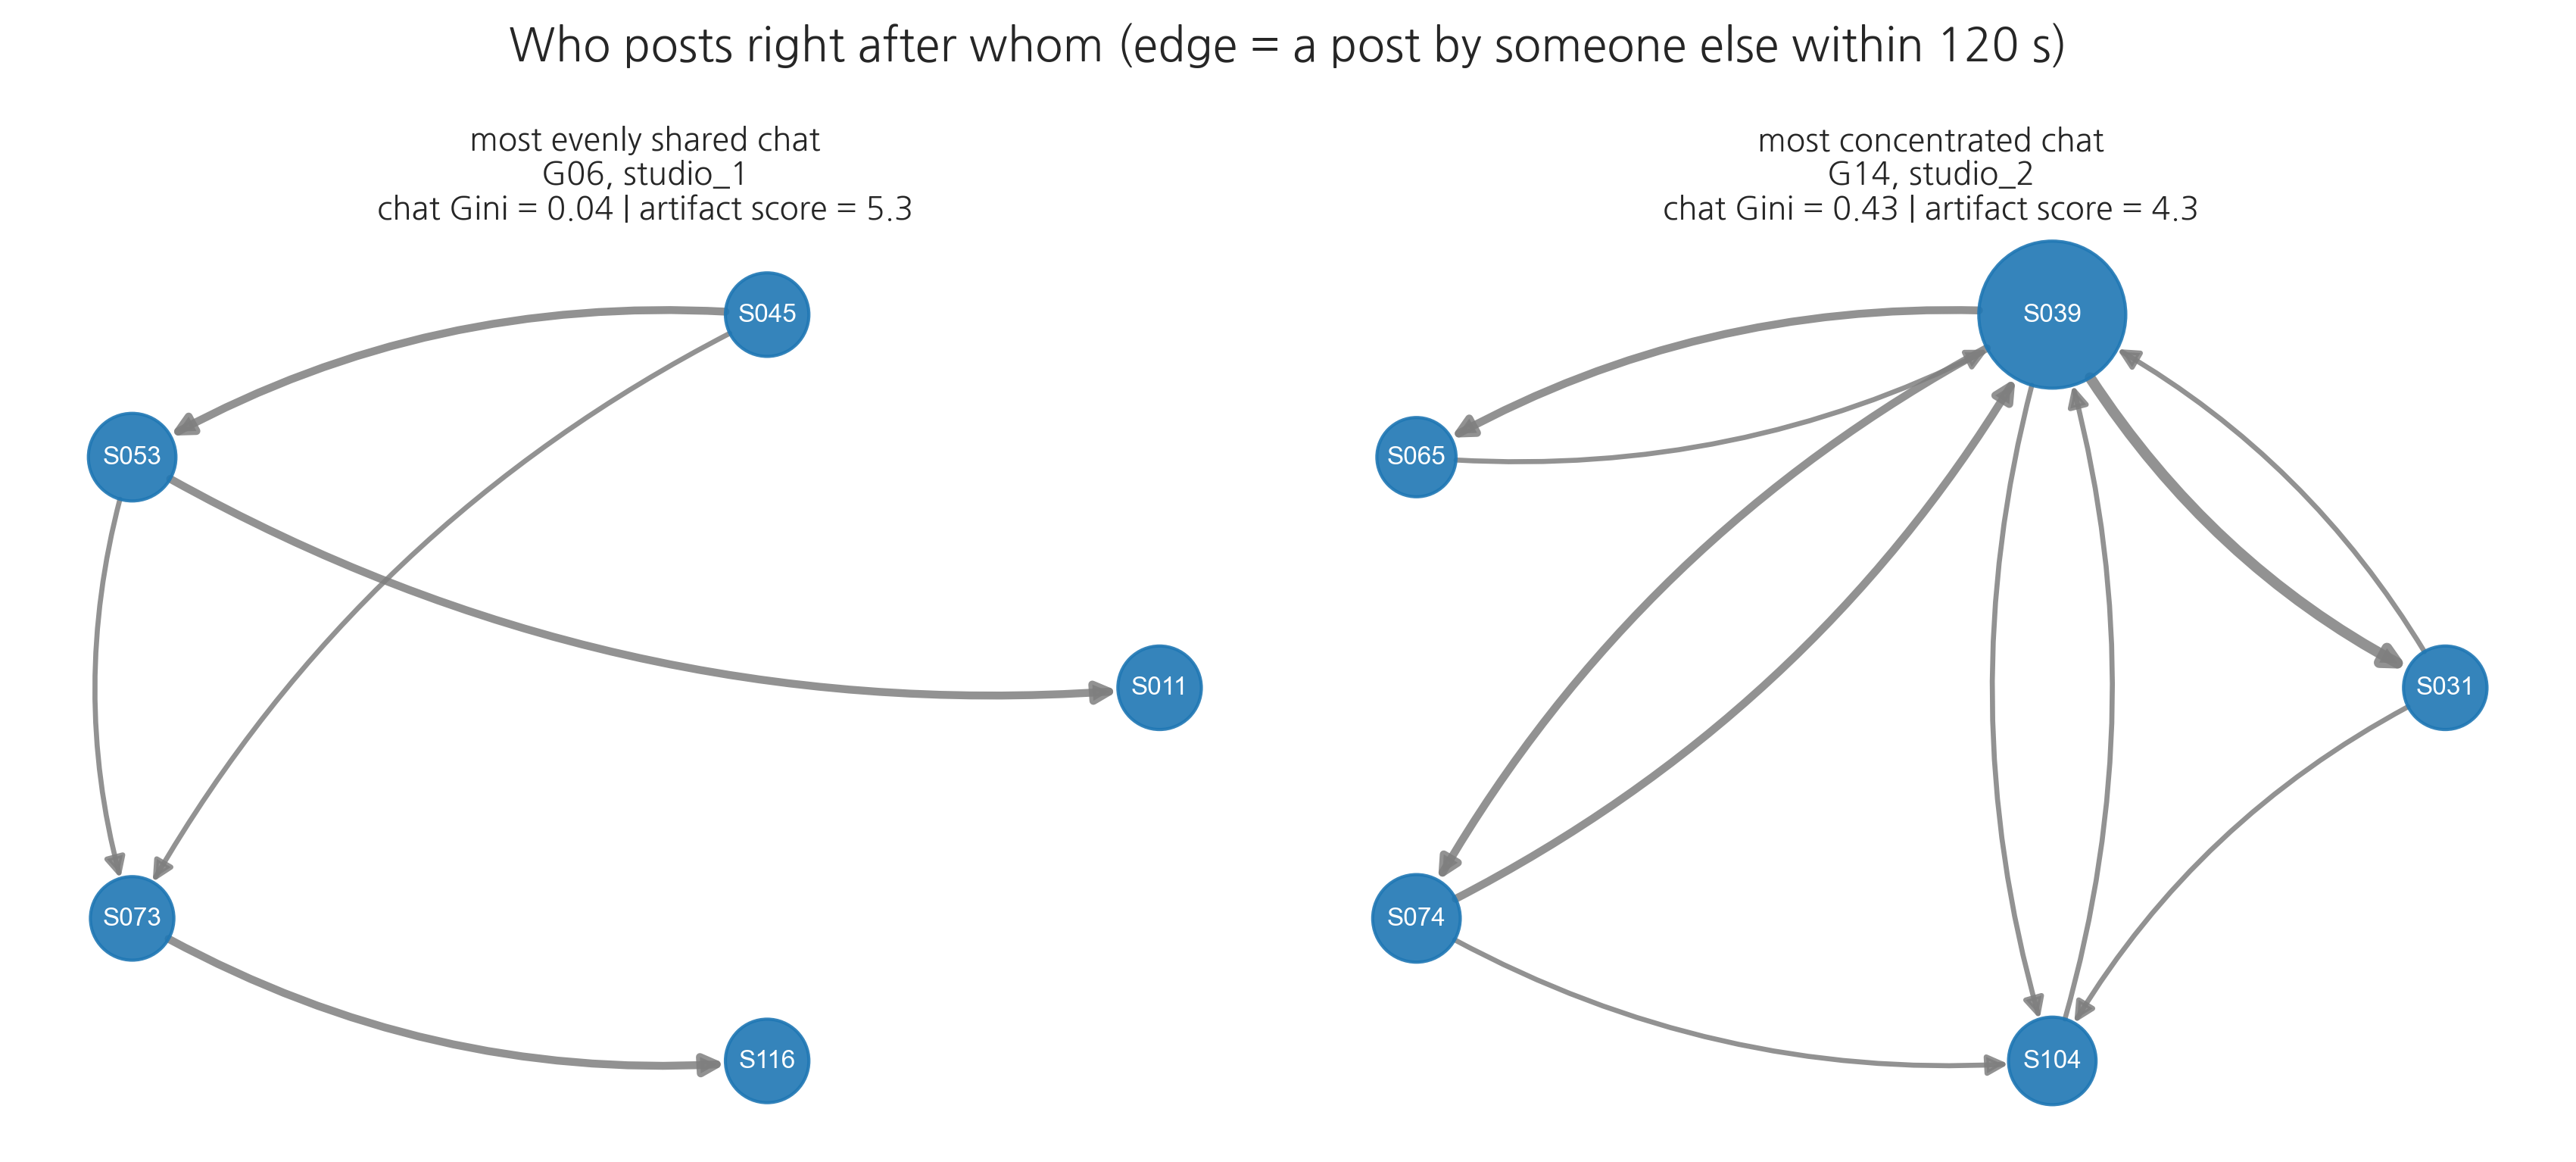


most evenly shared: G06 studio_1 (chat Gini 0.04)
      messages  followed_by_someone  followed_someone  share_of_messages_%
S053         5                    3                 2                 23.8
S011         4                    0                 2                 19.0
S045         4                    3                 0                 19.0
S073         4                    2                 2                 19.0
S116         4                    0                 2                 19.0

most concentrated: G14 studio_2 (chat Gini 0.43)
      messages  followed_by_someone  followed_someone  share_of_messages_%
S039        25                    8                 5                 59.5
S074         5                    3                 2                 11.9
S104         5                    1                 3                 11.9
S031         4                    2                 3                  9.5
S065         3                    1                 2                  7.1

In [11]:
REPLY_WINDOW_S = 120   # a message counts as following another only if it lands within this many seconds


def build_follow_graph(group_id, session_id, window_s=REPLY_WINDOW_S):
    # Directed graph of who posts right after whom inside one group-session.
    one = chat[(chat.group_id == group_id) & (chat.session_id == session_id)]
    roster_ids = sorted(mmla.loc[(mmla.group_id == group_id) &
                                 (mmla.session_id == session_id), "student_id"])
    G = nx.DiGraph()
    for sid in roster_ids:
        G.add_node(sid, n_messages=int((one.student_id == sid).sum()))
    for prev, curr, gap, switch in zip(one.prev_student, one.student_id, one.gap_s, one.is_switch):
        if pd.notna(prev) and switch and gap <= window_s:
            if G.has_edge(prev, curr):
                G[prev][curr]["weight"] += 1
            else:
                G.add_edge(prev, curr, weight=1)
    return G


def draw_sociogram(ax, group_id, session_id, headline, window_s=REPLY_WINDOW_S):
    G = build_follow_graph(group_id, session_id, window_s)
    pos = nx.circular_layout(G)
    sizes = [420 + 70 * G.nodes[n]["n_messages"] for n in G]
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=BLUE, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=ax)
    weights = [G[u][v]["weight"] for u, v in G.edges]
    nx.draw_networkx_edges(G, pos, width=[0.7 + 0.9 * w for w in weights], edge_color=GRAY,
                           connectionstyle="arc3,rad=0.16", arrowsize=13, ax=ax,
                           node_size=sizes, alpha=0.85)
    ax.set_title(headline, fontsize=10)
    ax.axis("off")
    return G


most_even = equity.sort_values("gini_chat").iloc[0]
most_uneven = equity.sort_values("gini_chat").iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
graphs = {}
for ax, row, tag in [(axes[0], most_even, "most evenly shared chat"),
                     (axes[1], most_uneven, "most concentrated chat")]:
    head = (f"{tag}\n{row.group_id}, {row.session_id}\n"
            f"chat Gini = {row.gini_chat:.2f} | artifact score = {row.artifact_score:.1f}")
    graphs[row.group_id] = draw_sociogram(ax, row.group_id, row.session_id, head)
fig.suptitle(f"Who posts right after whom (edge = a post by someone else within {REPLY_WINDOW_S} s)")
fig.tight_layout()
plt.show()

for row, tag in [(most_even, "most evenly shared"), (most_uneven, "most concentrated")]:
    G = graphs[row.group_id]
    tab = pd.DataFrame({
        "messages": [G.nodes[n]["n_messages"] for n in G.nodes],
        "followed_by_someone": [int(sum(d["weight"] for _, _, d in G.out_edges(n, data=True))) for n in G.nodes],
        "followed_someone": [int(sum(d["weight"] for _, _, d in G.in_edges(n, data=True))) for n in G.nodes],
    }, index=list(G.nodes)).sort_values("messages", ascending=False)
    tab["share_of_messages_%"] = (tab.messages / tab.messages.sum() * 100).round(1)
    print(f"\n{tag}: {row.group_id} {row.session_id} (chat Gini {row.gini_chat:.2f})")
    print(tab.to_string())

**🧐 Interpret these sociograms before you scroll.**

- In the concentrated group, one node is visibly a hub. Read the table with it: what share of the messages
  does that member hold, and how much of the group's turn taking passes through them?
- Both pictures come from groups of five people who all attended. The evenly shared group is not obviously
  the "better" group on the artifact score printed in the title. What does a single pair of cases license
  you to conclude? (The answer is close to nothing, which is exactly why Section 3 used all 192.)
- A hub can be a facilitator holding a group together or a person crowding everyone else out. The graph
  cannot tell them apart. What extra data would? What would it cost, in Praharaj and colleagues' (2021)
  terms, to collect it?

### ✏️ Your turn 3: the window is an argument

`REPLY_WINDOW_S` is not a fact about the group, it is your claim about how long a conversational thread
stays alive. Set it to 30 seconds and the graph shows rapid-fire exchanges only. Set it to 600 and almost
every consecutive pair becomes an edge.

Change `MY_WINDOW_S` below and watch the same session change shape. The default works as is.

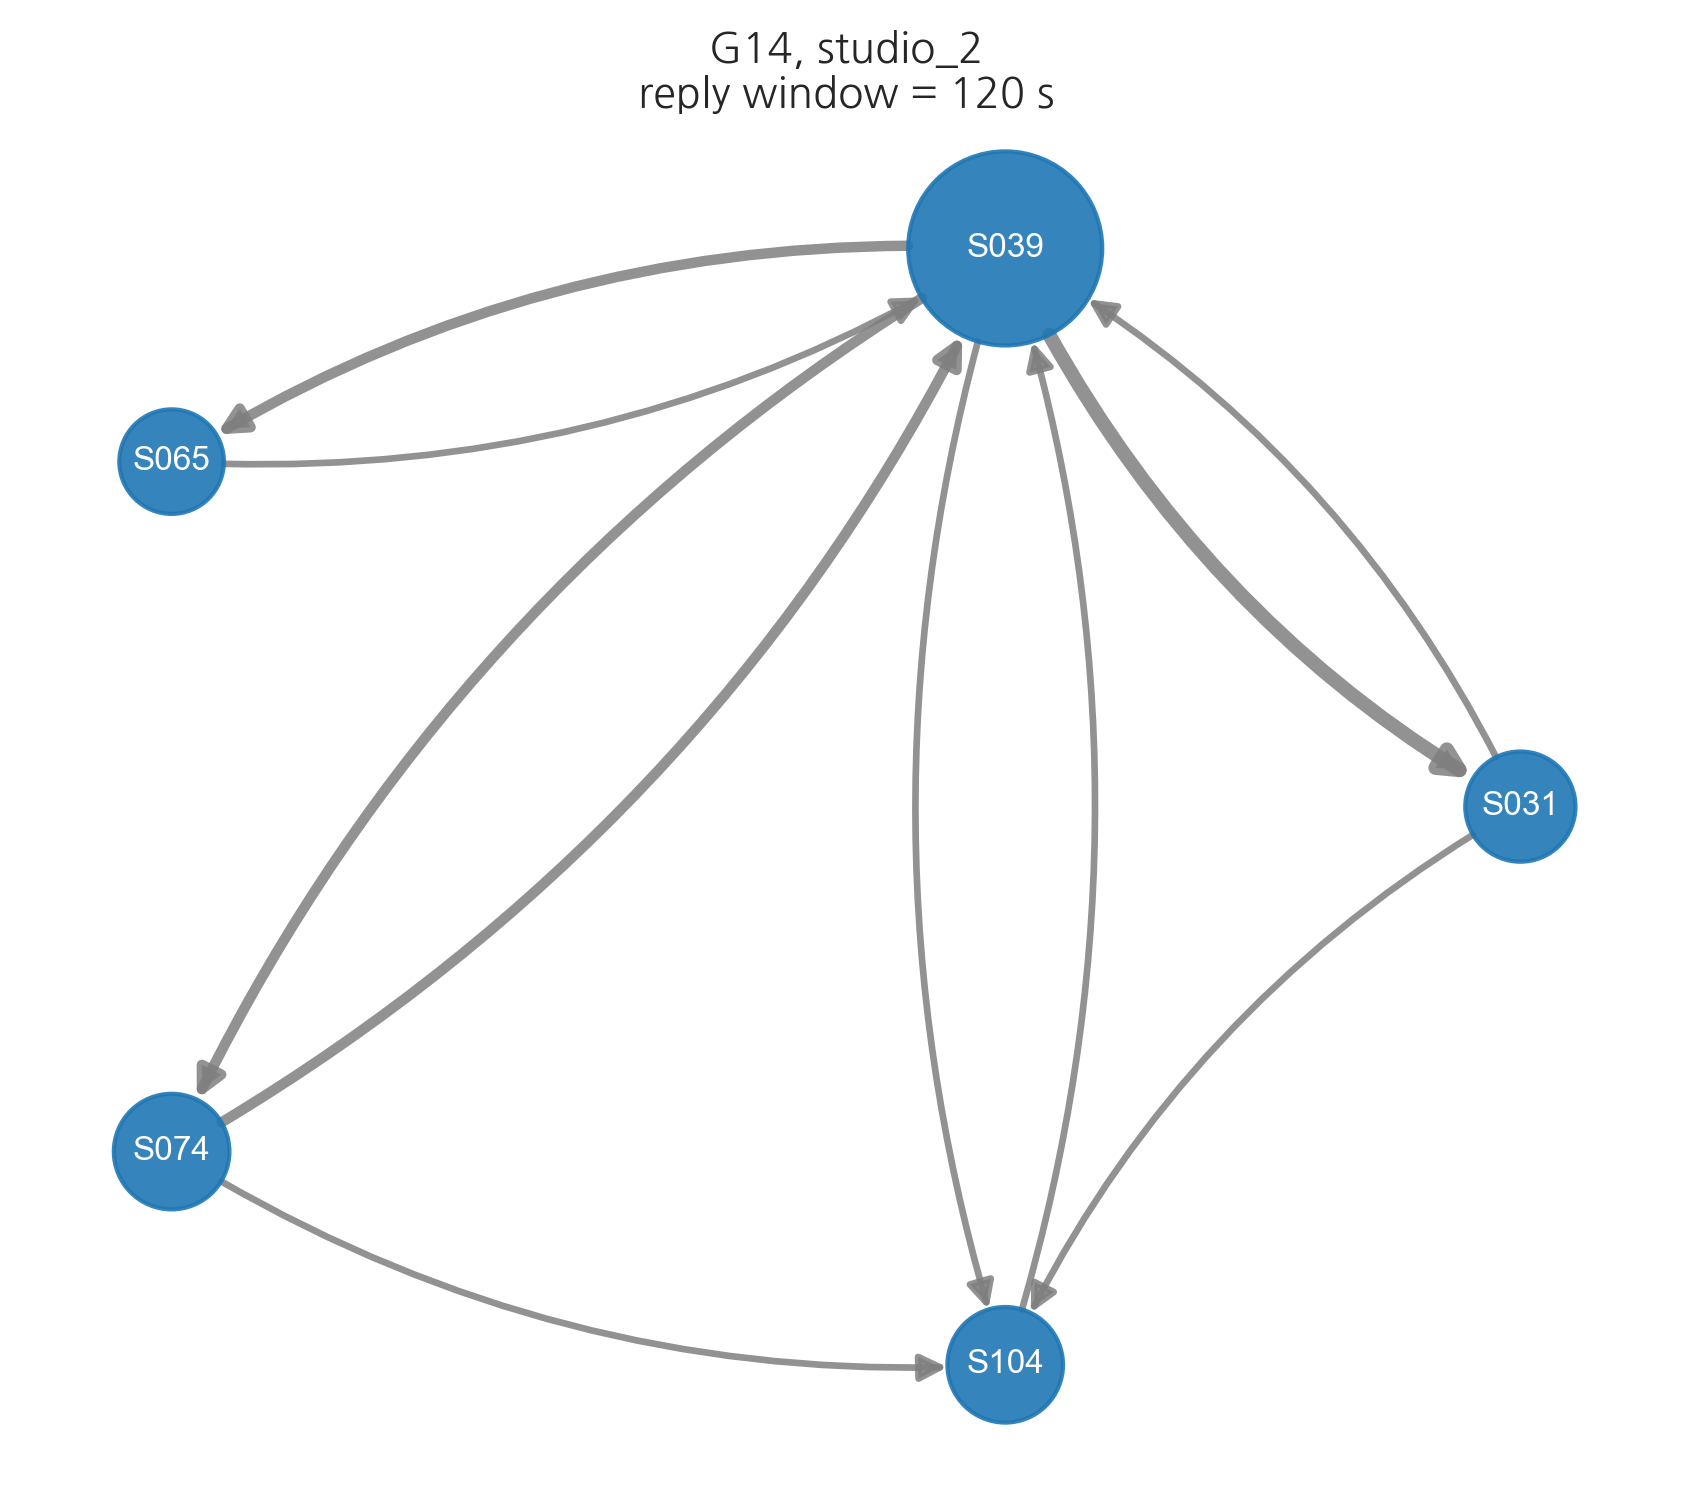

Reply window 120 s -> 10 of a possible 20 directed ties, 15 follow events total.
Density: 0.5


In [12]:
# TODO: try 30, then 300. Also try a group and session of your own choosing.
MY_WINDOW_S = 120
SOCIO_GROUP = "G14"
SOCIO_SESSION = "studio_2"

fig, ax = plt.subplots(figsize=(5.8, 5.2))
G = draw_sociogram(ax, SOCIO_GROUP, SOCIO_SESSION,
                   f"{SOCIO_GROUP}, {SOCIO_SESSION}\nreply window = {MY_WINDOW_S} s",
                   window_s=MY_WINDOW_S)
fig.tight_layout()
plt.show()

print(f"Reply window {MY_WINDOW_S} s -> {G.number_of_edges()} of a possible "
      f"{G.number_of_nodes() * (G.number_of_nodes() - 1)} directed ties, "
      f"{sum(d['weight'] for _, _, d in G.edges(data=True))} follow events total.")
print("Density:", round(nx.density(G), 3))

---

## 📊 Section 5. Which group signals actually move with the product?

We now have several candidate group level indicators. Rather than defending any one of them, we line them
all up against the same outcome and let the comparison do the arguing. Each bar is a correlation between
one group-session indicator and that session's artifact rubric score, across all 192 sessions.

Bar direction carries the sign, and the number is printed on every bar, so nothing here depends on telling
two colors apart.

**One thing to fix before we read any of it.** Those 192 rows are not 192 independent observations. They
are eight sessions from each of the same 24 groups, and a group that shares its floor unevenly in October
tends to do it again in November. The cell below measures how much of each indicator's variation lives
between groups rather than within them, converts that into an effective sample size, and recomputes every
correlation on the 24 group means. Read the group-level column. It is the one that answers a question
about groups.

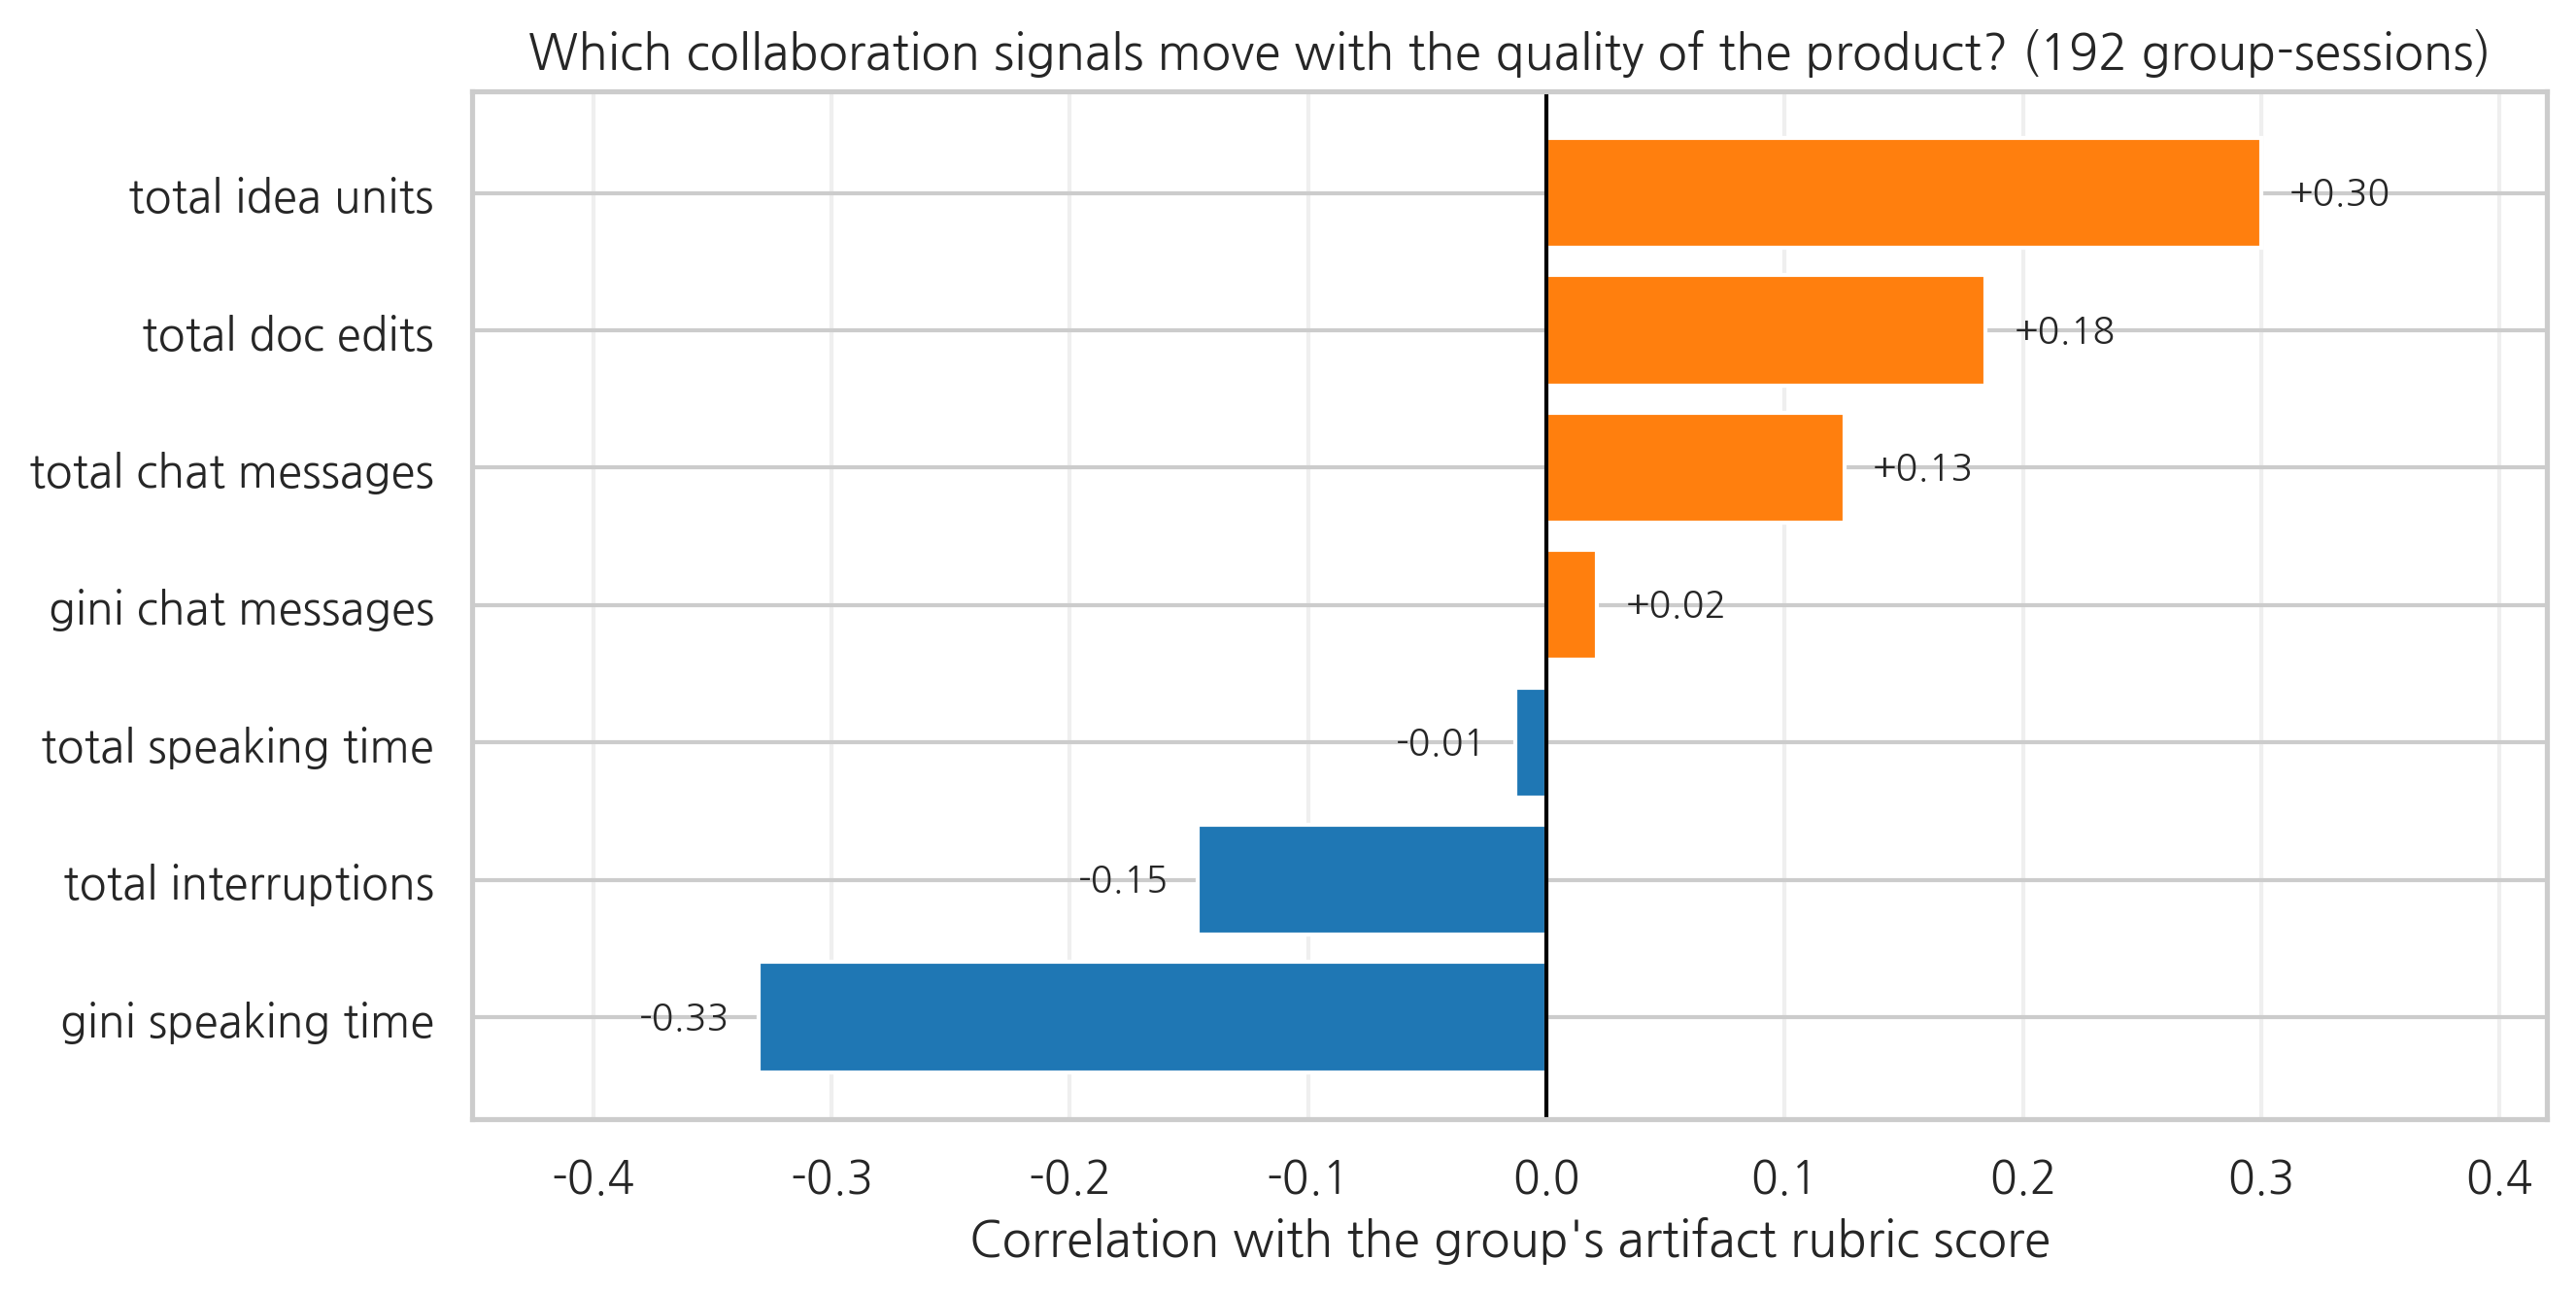

gini_speaking_time    -0.331
total_interruptions   -0.146
total_speaking_time   -0.013
gini_chat_messages     0.021
total_chat_messages    0.125
total_doc_edits        0.184
total_idea_units       0.300

The same indicators, checked for the fact that the 192 sessions come from 24 groups:

                     r_192_sessions  spearman_192  ICC_between_groups  effective_n  r_24_groups
indicator                                                                                      
gini_speaking_time           -0.331        -0.310               0.607       36.602       -0.522
total_speaking_time          -0.013        -0.007               0.026      162.163       -0.145
total_interruptions          -0.146        -0.152               0.087      119.467       -0.113
gini_chat_messages            0.021         0.016               0.129      100.833       -0.105
total_doc_edits               0.184         0.153               0.411       49.504        0.392
total_chat_messages           0.125   

In [13]:
group_features = (mmla.groupby(["group_id", "session_id"])
    .agg(gini_speaking_time=("speaking_time_s", gini),
         gini_chat_messages=("chat_messages", gini),
         total_idea_units=("idea_units_chat", "sum"),
         total_doc_edits=("doc_edits", "sum"),
         total_chat_messages=("chat_messages", "sum"),
         total_interruptions=("interruptions", "sum"),
         total_speaking_time=("speaking_time_s", "sum"))
    .reset_index()
    .merge(artifacts, on=["group_id", "session_id"]))

cors = (group_features.drop(columns=["group_id", "session_id"])
                      .corr()["artifact_score"].drop("artifact_score")
                      .sort_values())

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [BLUE if v < 0 else ORANGE for v in cors.values]
bars = ax.barh(cors.index.str.replace("_", " "), cors.values, color=colors, edgecolor="white")
for bar, v in zip(bars, cors.values):
    offset = 0.012 if v >= 0 else -0.012
    ax.text(v + offset, bar.get_y() + bar.get_height() / 2, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(cors.min() - 0.12, cors.max() + 0.12)
ax.set_xlabel("Correlation with the group's artifact rubric score")
ax.set_title("Which collaboration signals move with the quality of the product? (192 group-sessions)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

feature_cols = [c for c in group_features.columns
                if c not in ("group_id", "session_id", "artifact_score")]

# How much of each indicator sits between groups rather than within them? With 8 sessions per
# group, ICC rho inflates the variance of a correlation by roughly 1 + 7*rho (the design effect).
group_means = group_features.groupby("group_id")[feature_cols + ["artifact_score"]].mean()
rows = []
for col in feature_cols:
    g = group_features.groupby("group_id")[col]
    ms_between, ms_within = g.mean().var(ddof=1) * 8, g.var(ddof=1).mean()
    icc = max(0.0, (ms_between - ms_within) / (ms_between + 7 * ms_within))
    rows.append({
        "indicator": col,
        "r_192_sessions": group_features[col].corr(group_features.artifact_score),
        "spearman_192": group_features[col].corr(group_features.artifact_score, method="spearman"),
        "ICC_between_groups": icc,
        "effective_n": 192 / (1 + 7 * icc),
        "r_24_groups": group_means[col].corr(group_means.artifact_score),
    })
check = pd.DataFrame(rows).set_index("indicator").sort_values("r_24_groups")

print(cors.round(3).to_string())
print("\nThe same indicators, checked for the fact that the 192 sessions come from 24 groups:\n")
print(check.round(3).to_string())
print("\nHow to read that table. At 192 genuinely independent observations, |r| past about 0.14 would")
print("clear the conventional p < .05 bar. These are not independent. The ICC column says how much of")
print("each indicator is a stable property of a group rather than of a session, and effective_n is what")
print("192 rows are really worth once that is accounted for. Speaking time inequality is the extreme")
print("case: 61 percent of it lives between groups, so 192 sessions carry about as much information as")
print("37 independent observations would.")
print("\nAt 24 groups the bar moves to |r| past about 0.40, and the group-level column reshuffles the")
print("ranking. Read three rows in particular:")
for name in ["gini_speaking_time", "total_chat_messages", "total_interruptions"]:
    row = check.loc[name]
    print(f"  {name:20s} {row.r_192_sessions:+.2f} across sessions -> "
          f"{row.r_24_groups:+.2f} across groups")
print("Nothing about the groups changed between those two columns. Only the question did.")

**🧐 Interpret this chart before you scroll.**

- The strongest positive bar is the volume of *coded substantive contributions* in chat, not the volume of
  chat. The strongest negative bar is the inequality of *speaking time*, not the inequality of chat.
- It is tempting to read that as "the expensive measure wins and the cheap ones fail," and Your turn 2
  will show you that reading is wrong. `num_turns` comes free with the same microphones that give you
  speaking time, costs nothing extra to count, and lands at -0.33 alongside it. What separates the
  indicators here is not what they cost. It is **which channel they listen to**: everything from the
  audio carries signal about this outcome and everything from raw chat volume does not. Rewrite the
  cost sentence as a channel sentence.
- Total speaking time barely moves the outcome. Total idea units does. Say what that means for a group that
  was quiet for 20 minutes because everyone was reading.
- Compare the 192-session column against the 24-group column in the printed table. Total chat messages
  moves from +0.13 to +0.41 and total interruptions moves from -0.15 to -0.11, so the second column
  promotes one indicator and demotes another. Nothing about the groups changed; only the question did.
  Which of the two columns answers "do groups that share the floor make better products," and what is
  the unit of the sentence you would actually write?
- Group ability is nowhere in any of this. Write the caveat sentence you would attach if this figure
  appeared in your course project.

### The equity check you should run before shipping any of this

One more pass, and it is the one that decides whether a dashboard helps or harms. A measure that reads
one group of students as contributing less than the other channels show them contributing is not a
neutral instrument. It is a policy, and somebody will act on it.

Twenty four students on this roster use more than one language day to day. Below we compare their average
recorded participation against everyone else's, in four channels at once. A value of 1.0 means the two
groups are recorded identically on that channel. Because 24 is a small number, each ratio comes with a
bootstrap interval; a ratio whose interval contains 1.0 is a ratio you cannot yet tell apart from parity.

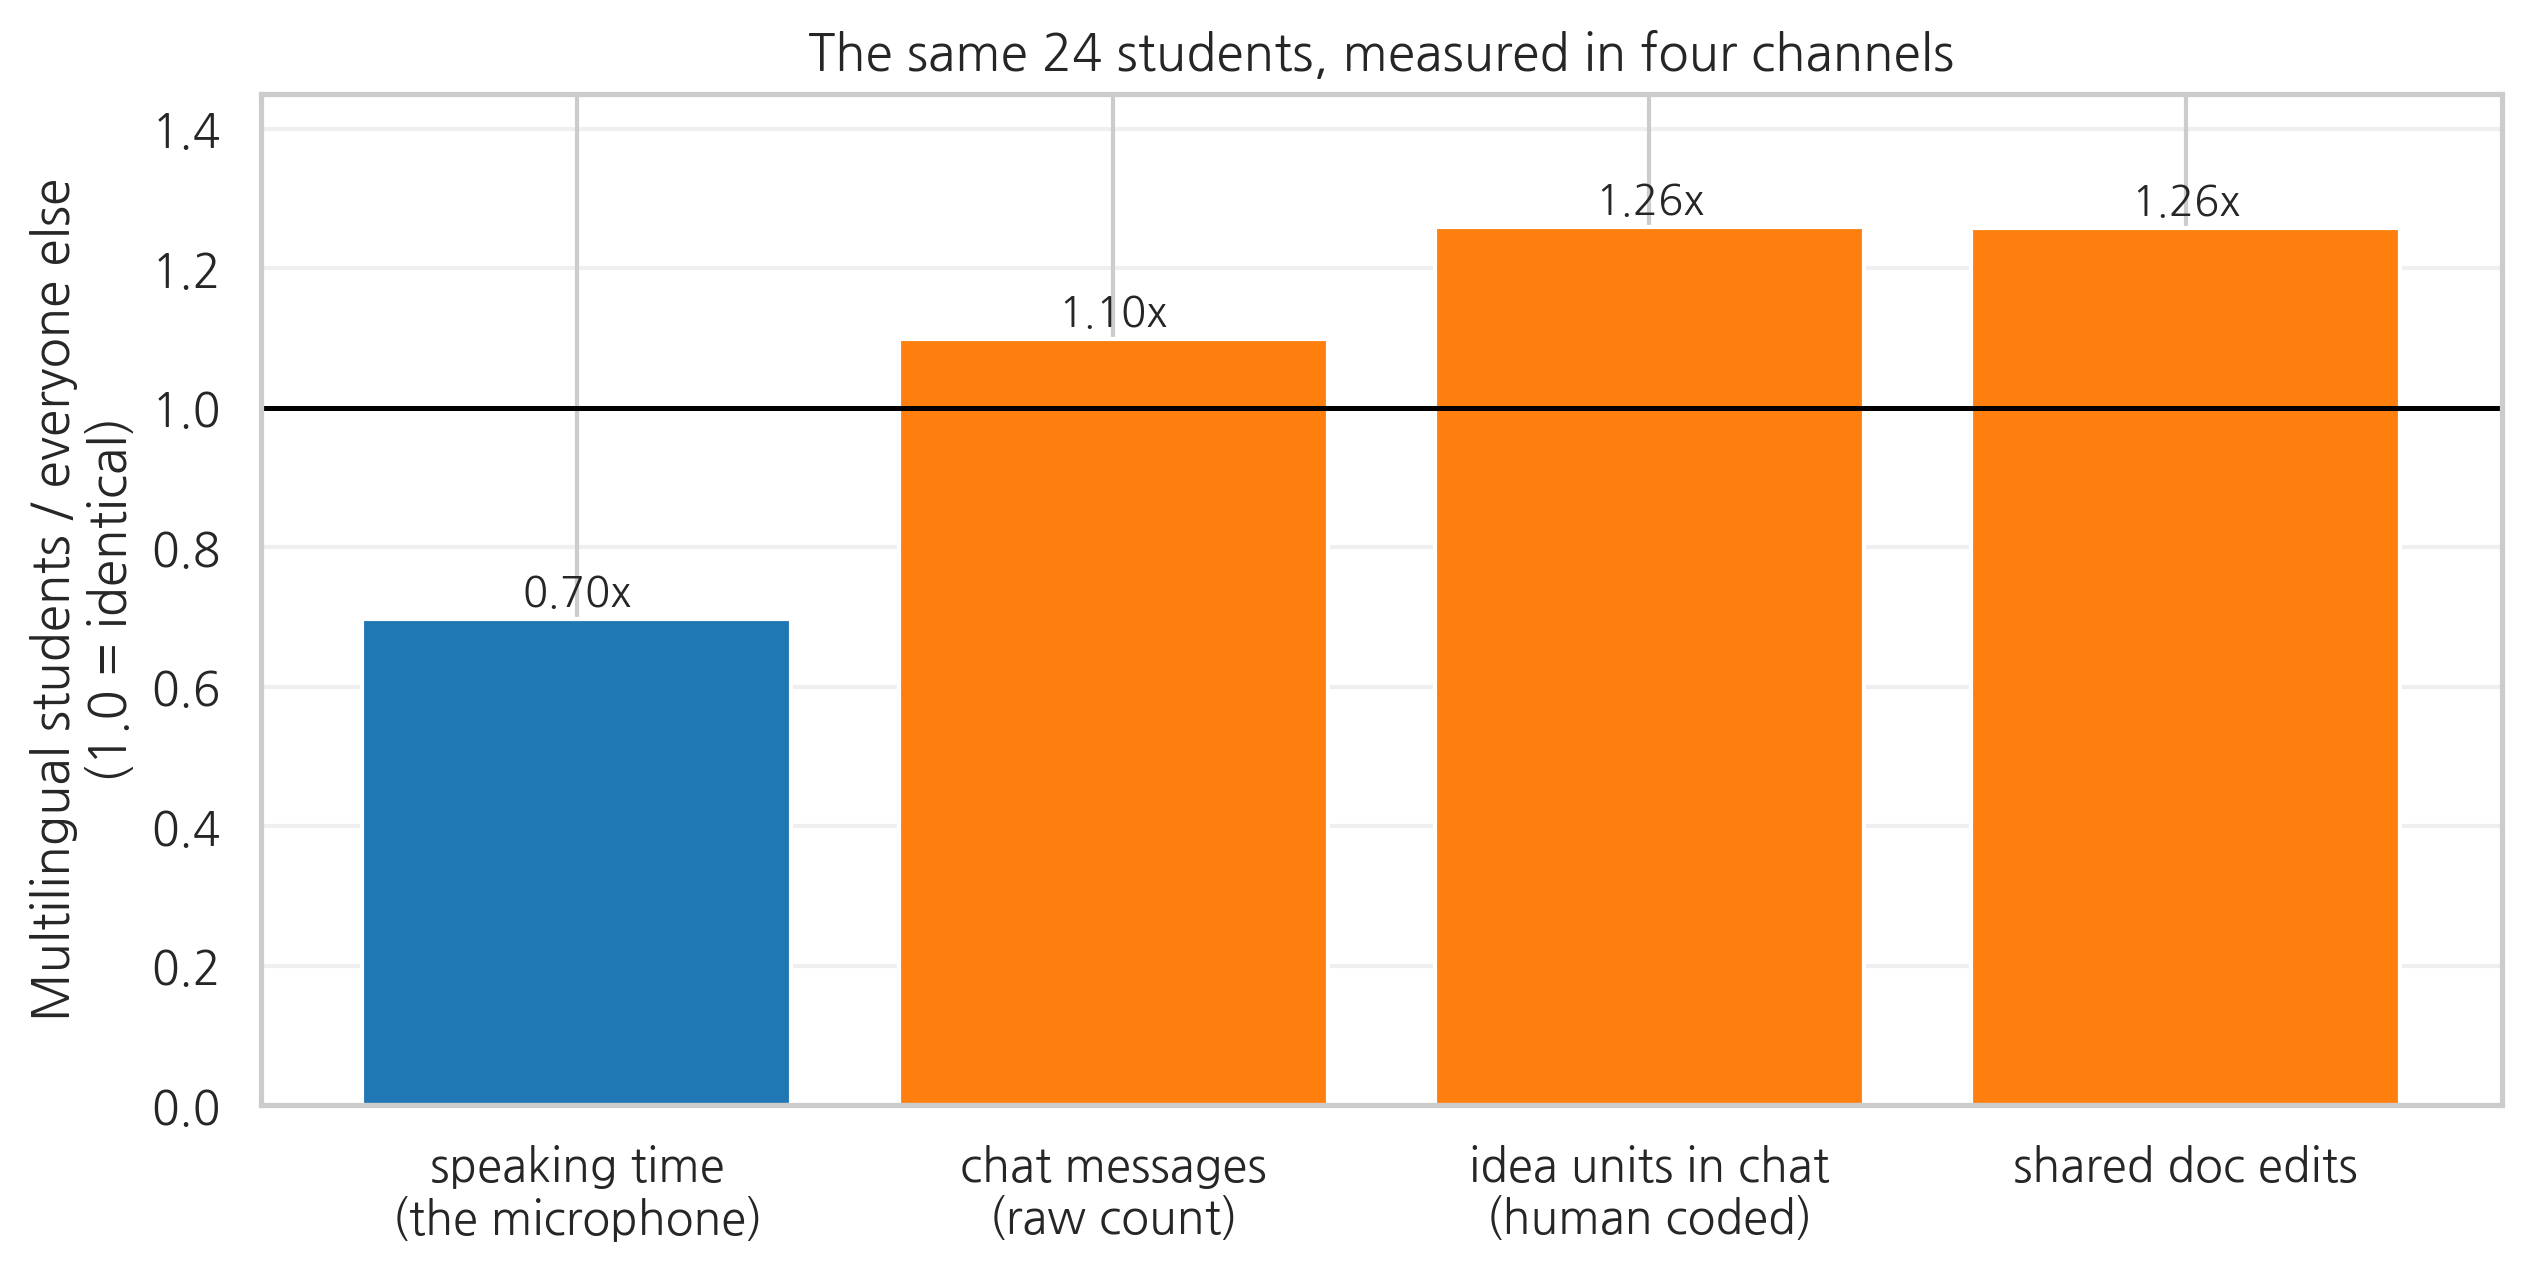

                 not multilingual (n=96)  multilingual (n=24)  ratio  95% interval tells apart from 1.0?
speaking_time_s                   5230.7               3643.5   0.70  [0.51, 0.92]                   yes
chat_messages                       52.1                 57.3   1.10  [0.93, 1.28]                    no
idea_units_chat                     18.2                 22.9   1.26  [1.03, 1.53]                   yes
doc_edits                           29.4                 37.0   1.26  [1.01, 1.55]                   yes

With 24 students in one group and 96 in the other, one of these four ratios cannot be
distinguished from parity. Say which, out loud, before you read the next cell.


In [14]:
per_student = (mmla.groupby("student_id")
                   .agg(speaking_time_s=("speaking_time_s", "sum"),
                        chat_messages=("chat_messages", "sum"),
                        idea_units_chat=("idea_units_chat", "sum"),
                        doc_edits=("doc_edits", "sum"))
                   .reset_index()
                   .merge(students[["student_id", "multilingual"]], on="student_id"))

channels = ["speaking_time_s", "chat_messages", "idea_units_chat", "doc_edits"]
pretty = ["speaking time\n(the microphone)", "chat messages\n(raw count)",
          "idea units in chat\n(human coded)", "shared doc edits"]
means = per_student.groupby("multilingual")[channels].mean()
ratio = (means.loc[1] / means.loc[0])

fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ax.bar(pretty, ratio[channels].values,
              color=[BLUE if v < 1 else ORANGE for v in ratio[channels].values],
              edgecolor="white")
for bar, v in zip(bars, ratio[channels].values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}x", ha="center", fontsize=10)
ax.axhline(1.0, color="black", lw=1.2)
ax.set_ylim(0, 1.45)
ax.set_ylabel("Multilingual students / everyone else\n(1.0 = identical)")
ax.set_title("The same 24 students, measured in four channels")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

table = means.T.round(1)
table.columns = ["not multilingual (n=96)", "multilingual (n=24)"]
table["ratio"] = ratio.round(2).values

# Bootstrap interval for each ratio: resample students within each group, 2000 times.
boot_rng = np.random.default_rng(8100)
a_idx = per_student.index[per_student.multilingual == 1].to_numpy()
b_idx = per_student.index[per_student.multilingual == 0].to_numpy()
lo_hi = {}
for ch in channels:
    a_vals = per_student.loc[a_idx, ch].to_numpy()
    b_vals = per_student.loc[b_idx, ch].to_numpy()
    draws = (a_vals[boot_rng.integers(0, a_vals.size, (2000, a_vals.size))].mean(axis=1)
             / b_vals[boot_rng.integers(0, b_vals.size, (2000, b_vals.size))].mean(axis=1))
    lo_hi[ch] = np.percentile(draws, [2.5, 97.5])
table["95% interval"] = [f"[{lo_hi[c][0]:.2f}, {lo_hi[c][1]:.2f}]" for c in table.index]
table["tells apart from 1.0?"] = ["yes" if (lo_hi[c][0] > 1) or (lo_hi[c][1] < 1) else "no"
                                  for c in table.index]
print(table.to_string())
print("\nWith 24 students in one group and 96 in the other, one of these four ratios cannot be")
print("distinguished from parity. Say which, out loud, before you read the next cell.")

**🧐 Interpret this chart before you scroll.**

- A dashboard that defines participation as speaking time reports these 24 students at roughly 0.7 times
  their peers, and the interval stays below 1.0. A dashboard that defines it as coded ideas in chat
  reports them at about 1.26 times, and that interval stays above 1.0. Same students, same sessions,
  opposite conclusion. Which dashboard is wrong?
- The raw chat message ratio is 1.10 with an interval straddling 1.0, which means this file cannot tell
  you whether those students send more messages or fewer. Notice how easy it would have been to print
  "1.10x" on a slide and let a reader take it as a finding.
- Suppose the speaking time version is live and a teacher uses it to decide who to call on. Trace the
  consequence forward three steps.
- Now the harder version of the question. Suppose you build the good dashboard, the one that combines
  channels fairly. Should the group see each member's numbers? Should a student see how they compare to
  their own group? Hold your answers for the reflection.

### ✏️ Your turn 4: write the dashboard's refusal list

This is the design question, and it is the reason this lab exists. Below is a draft specification for a
collaboration dashboard for EDUC 1010's studio sessions. For each tile you decide the audience:

- `"teacher"`: only the instructor sees it
- `"group"`: displayed to the whole group during or after the session
- `"student"`: each student sees only their own value
- `"nobody"`: the tile is not built, or is built and never displayed

The code checks your specification against a short list of design hazards drawn from this notebook's
findings and prints a review. The defaults already produce a coherent (and arguable) spec, so the cell
runs untouched. Change at least three of them, and be ready to defend the changes in discussion.

In [15]:
# TODO: edit the audience for each tile. Options: "teacher", "group", "student", "nobody".
dashboard_spec = {
    "group_chat_volume":         "group",
    "median_response_latency":   "teacher",
    "speaking_time_gini":        "teacher",
    "chat_message_gini":         "nobody",
    "per_member_speaking_time":  "student",
    "per_member_message_count":  "nobody",
    "sociogram_of_the_group":    "teacher",
    "coded_idea_units":          "teacher",
    "multilingual_flag":         "nobody",
    "predicted_artifact_score":  "nobody",
}

HAZARDS = {
    "median_response_latency": ("Section 2: this metric is largely a restatement of chat volume "
                                "(r = -0.72). Displayed as responsiveness, it mislabels quiet, "
                                "working groups.", {"group", "student"}),
    "chat_message_gini":       ("Section 3: unrelated to product quality (r = +0.02) and unrelated to "
                                "speaking equity. It looks like an equity measure and is not one.",
                                {"group", "student", "teacher"}),
    "per_member_message_count": ("Section 1: message counts equate 'ok' with a substantive claim, and "
                                 "displaying them to peers turns a proxy into a performance target.",
                                 {"group"}),
    "per_member_speaking_time": ("Section 5: reads multilingual students at 0.70x their peers. Shown to "
                                 "the group, it publicly ranks students on the one channel where this "
                                 "measure is least fair.", {"group"}),
    "sociogram_of_the_group":  ("Section 4: an arrow means 'posted soon after', not 'replied to'. Shown "
                                 "to the group it becomes a social diagram people will read as a "
                                 "popularity map.", {"group", "student"}),
    "multilingual_flag":       ("Never a dashboard tile. It marks a person as a category and invites the "
                                 "deficit reading the data refuse to support.", {"teacher", "group", "student"}),
    "predicted_artifact_score": ("A prediction shown before the work is finished can become the reason "
                                 "the prediction comes true.", {"group", "student"}),
}

print("COLLABORATION DASHBOARD SPECIFICATION")
print("=" * 74)
for tile, audience in dashboard_spec.items():
    mark = "  " if audience == "nobody" else "> "
    print(f"{mark}{tile:28s} -> {audience}")

print("\nDESIGN REVIEW")
print("=" * 74)
flags = 0
for tile, audience in dashboard_spec.items():
    if tile in HAZARDS:
        note, risky_audiences = HAZARDS[tile]
        if audience in risky_audiences:
            flags += 1
            print(f"\n[!] {tile} -> {audience}")
            print(f"    {note}")
if flags == 0:
    print("\nNo hazard on the list was triggered. That is not the same as a safe dashboard:")
    print("the list only contains hazards this notebook happened to surface.")
else:
    print(f"\n{flags} tile(s) flagged. A flag is not a verdict. It is the start of the argument you")
    print("have to make in writing, to the people whose collaboration is on the screen.")

shown = sum(1 for a in dashboard_spec.values() if a != "nobody")
print(f"\nYou chose to display {shown} of {len(dashboard_spec)} tiles.")
print("Every tile you kept is a claim you are willing to defend to a student who disagrees with it.")

COLLABORATION DASHBOARD SPECIFICATION
> group_chat_volume            -> group
> median_response_latency      -> teacher
> speaking_time_gini           -> teacher
  chat_message_gini            -> nobody
> per_member_speaking_time     -> student
  per_member_message_count     -> nobody
> sociogram_of_the_group       -> teacher
> coded_idea_units             -> teacher
  multilingual_flag            -> nobody
  predicted_artifact_score     -> nobody

DESIGN REVIEW

No hazard on the list was triggered. That is not the same as a safe dashboard:
the list only contains hazards this notebook happened to surface.

You chose to display 6 of 10 tiles.
Every tile you kept is a claim you are willing to defend to a student who disagrees with it.


---

## 💬 Reflection

Write short answers in the cell below (or in your own notes). Bring one of them to the discussion.

**1. The modality problem.** Chen and Teasley (2022) argue that collaboration analytics has to specify the
construct before it specifies the sensor. In this notebook, speaking time equity related to artifact
quality and chat message equity did not. Write two sentences: one that treats this as a measurement
failure, and one that treats it as evidence that talk and chat carry different kinds of contribution.
Which sentence would you defend, and what study would decide between them?

**2. Principles and dilemmas.** Martinez-Maldonado, Kay, Buckingham Shum, and Yacef (2019) set out
principles and dilemmas for mining multimodal interaction data in collocated groups. Pick one dilemma you
felt while working through Sections 4 and 5, name it in your own words, and say how you resolved it in your
Your Turn 4 specification. If you resolved it by not building the tile, say what is lost by not building it.

**3. The whole nine yards.** Praharaj, Scheffel, Drachsler, and Specht (2021) ask whether co-located
collaboration modeling can go the whole nine yards from sensing to feedback. Section 5 gave you a
tangle worth untangling in writing. The strongest positive signal, human coded idea units, is the most
expensive thing on the list to collect. The strongest signal of any sign, inequality of speaking time,
is a group level number that comes free with the microphones. And the equity check found that the
*per student* version of that same microphone channel records multilingual students at about 0.7 times
their peers while three other channels record them at or above parity. Those are two different claims
about the same sensor, one at the group level and one at the person level, and only the second is an
equity finding. Separate them carefully, then answer: what should a school do that can afford the
microphones but not the coders?

**4. The refusal.** Finish this sentence with something you would actually defend in a faculty meeting:
"A collaboration dashboard for this course should not show ______ to ______, because ______."
Then answer the follow up that always comes next: who gets to make that decision, and were the students
in the room when it was made?

**5. Back to your own project.** Your Course Research Project Outline is due this week. Name one
measurement decision in your proposal that is the same *kind* of decision as choosing chat counts over
speaking time. Write the sentence in your outline that acknowledges it.

In [16]:
# Type your answers between the quotes. This cell just holds your writing, nothing depends on it.
answer_1_modality = "..."
answer_2_dilemma = "..."
answer_3_nine_yards = "..."
answer_4_refusal = "A collaboration dashboard for this course should not show ... to ... because ..."
answer_5_my_project = "..."

for label, text in [("1. The modality problem", answer_1_modality),
                    ("2. Principles and dilemmas", answer_2_dilemma),
                    ("3. The whole nine yards", answer_3_nine_yards),
                    ("4. The refusal", answer_4_refusal),
                    ("5. Back to my own project", answer_5_my_project)]:
    print(f"{label}\n   {text}\n")

1. The modality problem
   ...

2. Principles and dilemmas
   ...

3. The whole nine yards
   ...

4. The refusal
   A collaboration dashboard for this course should not show ... to ... because ...

5. Back to my own project
   ...



---

## ✅ Submission checklist

This week is **not** a mini project week, so this notebook is not itself a graded submission. What is due
this week is the **Course Research Project Outline**, and it is submitted separately from this notebook.

Due this week (Canvas):

- [ ] **Course Research Project Outline**, using the Week 09 outline template: problem and context,
      conceptual framework, research questions, data plan, methods, ethics and equity, actionability,
      references in APA 7.
- [ ] **AI interaction log**, if you used any AI tool while preparing the outline or while working through
      this notebook. Per the course AI policy, AI use is permitted in designated activities and must be
      documented. Paste the full exchanges into a Word file and attach it to the Canvas "AI Reflection"
      submission, not into the text box.
- [ ] **AI reflection**, typed into the text box on that same page: copy in and answer the four questions
      from the syllabus, on how you used it, whether it helped, whether it made anything harder, and what
      lesson you would pass on. Undisclosed AI use is an Honor Code violation.

Recommended for your own records, not submitted:

- [ ] Save a copy of this notebook with your outputs (**File > Save a copy in Drive** in Colab).
- [ ] Keep your Your Turn 4 dashboard specification. Week 11's co-design studio starts from exactly this
      kind of artifact, and a specification you already argued with is a good place to start.

---

## 🧗 Stretch goals (optional, for after class)

None of these are required, and none of them are graded. They are here because some of you will want them.

1. **A fairer composite index.** Build a single participation score per student-session that combines
   speaking time, coded idea units, and doc edits (standardize each channel first, then average). Recompute
   the Gini on that composite. Does its relationship to artifact score look more like the talk version or
   the chat version? What did you smuggle in when you chose equal weights?
2. **Turn taking beyond chance.** In a group where one member sends 40 percent of the messages, that member
   will appear in 40 percent of the follow edges by arithmetic alone. Compute the expected edge weights
   under a null model where turn order is independent of who spoke last, and plot observed minus expected.
   Which ties survive?
3. **Trajectories, not snapshots.** Chat Gini for each group across `studio_1` to `studio_8`. Do groups
   settle into a pattern, or does the pattern move? A dashboard showing session 3 alone would say what
   about the groups that changed?
4. **The silence.** Nine member-sessions had zero chat messages. Pull those students' speaking time and doc
   edits for the same sessions. What were they actually doing, and what would a chat-only dashboard have
   said about them?
5. **The nested structure, properly.** Section 5 handles the 24-groups-by-8-sessions structure by
   aggregating. Do it the other way instead: fit a mixed effects model of artifact score on speaking
   time Gini with a random intercept for group, and compare the fixed effect against both the 192-row
   and the 24-row correlations. Then say which of the three you would report, and to whom.

---

## 📎 Appendix: solutions to the Your turn cells

Copy any of these into a cell and run it. They are one way to do each task, not the only way.

### Your turn 1: look at a different room

Any valid pair works. To find the most lopsided session in the dataset first, and then look at it:

```python
worst = equity.sort_values("gini_chat").iloc[-1]
print(worst.group_id, worst.session_id, round(worst.gini_chat, 2))
plot_turn_raster(worst.group_id, worst.session_id)
```

To find the most evenly shared one, use `.iloc[0]` instead. Note that you need to have run Section 3
before `equity` exists.

### Your turn 2: swap in a better chat measure

```python
MEASURE = "idea_units_chat"
```

Equity of coded idea units comes back at r = -0.08 against +0.02 for raw message counts. Resist the
urge to call that an improvement: with 192 sessions clustered in 24 groups, neither is distinguishable
from zero, and the honest sentence is that both chat-based equity measures are silent about this
outcome. Running the same cell with `"doc_edits"` (-0.08), `"num_turns"` (-0.33), and
`"speaking_time_s"` (-0.33) gives you five points of comparison.

The pattern worth noticing is not about cost. `num_turns` is as cheap to collect as message counts,
comes off the same microphones as speaking time, and lands at -0.33 with them. It is the **channel**
that decides whether equity carries signal here, not the price of the instrument. Any argument of the
form "we could only afford the cheap measures, so we could not find anything" is refuted by that one
column.

### Your turn 3: the window is an argument

```python
MY_WINDOW_S = 30     # then 120, then 600
```

At 30 seconds you keep only rapid exchanges, the graph thins out, and quiet groups can end up with almost
no edges at all, which will look like disconnection when it is really just pace. At 600 seconds nearly
every consecutive pair of messages becomes a tie and the density approaches its ceiling, so every group
looks equally connected. Neither extreme is wrong. Both are claims about how long a conversational thread
stays open, and the sensible move is to report the window you chose and show that your conclusion survives
a different one.

### Your turn 4: the refusal list

There is no answer key here, only better and worse arguments. A defensible specification that this
notebook supports:

```python
dashboard_spec = {
    "group_chat_volume":         "teacher",
    "median_response_latency":   "nobody",     # Section 2: it is a chattiness metric wearing a costume
    "speaking_time_gini":        "teacher",    # real signal, but not a public scoreboard
    "chat_message_gini":         "nobody",     # r = +0.02 with the outcome; it measures nothing we want
    "per_member_speaking_time":  "student",    # your own number, not your ranking against peers
    "per_member_message_count":  "nobody",
    "sociogram_of_the_group":    "teacher",
    "coded_idea_units":          "teacher",
    "multilingual_flag":         "nobody",
    "predicted_artifact_score":  "nobody",
}
```

The reasoning that matters is not which slot each tile lands in. It is the principle underneath: a measure
may be displayed to an audience only if that audience can act on it in a way that helps, and only if being
wrong about a person costs less than staying silent. By that test, most per member comparisons fail at the
group level and survive at the individual level, and the multilingual flag fails everywhere.